In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import missingno as msno
warnings.filterwarnings('ignore')
import math
from scipy.stats import chi2_contingency,f_oneway,jarque_bera,probplot

In [2]:
# why is accurate time prediction important ?
#Ans :- It helps all the 3 stakeholders ie customers , riders and restaurant partners . With exac time customer can understand whether to place the order or not , a estimated time given to rider before picking the order can help him to navigate best possible routes and time given to restaurants will help them to queue their food orders or priotize which order to make first or later

In [3]:
df = pd.read_csv('swiggy.csv')

In [4]:
df.rename(columns={'Time_taken(min)':'time_taken'},inplace=True)

In [5]:
df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,time_taken
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26


In [6]:
rows,cols = df.shape
print('The number of rows is {} and the number of columns is {}'.format(rows,cols))

The number of rows is 45593 and the number of columns is 20


In [7]:
df.isna().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
time_taken                     0
dtype: int64

In [8]:
df['City_name'] = df.Delivery_person_ID.str.split('RES').str[0].map({'INDO':'Indore','BANG':'Bangalore','COIMB':'Coimbatore','CHEN':'Chennai','HYD':'Hyderabad','RANCHI':'Ranchi','MYS':'Mysore','DEH':'Delhi','KOC':'Kochi','PUNE':'Pune','LUDH':'Ludhiana','KNP':'Kanpur','MUM':'Mumbai','KOL':'Kolkata','JAP':'Jaipur','SUR':'Surat','GOA':'Goa','AURG':'Aurangabad','AGR':'Agra','VAD':'Vadodara','ALH':'Allahabad','BHP':'Bhopal'})

In [9]:
df.City_name.unique()

array(['Indore', 'Bangalore', 'Coimbatore', 'Chennai', 'Hyderabad',
       'Ranchi', 'Mysore', 'Delhi', 'Kochi', 'Pune', 'Ludhiana', 'Kanpur',
       'Mumbai', 'Kolkata', 'Jaipur', 'Surat', 'Goa', 'Aurangabad',
       'Agra', 'Vadodara', 'Allahabad', 'Bhopal'], dtype=object)

In [10]:
df.Delivery_person_Ratings = df.Delivery_person_Ratings.astype(float)

In [11]:
a = df[df.Time_Orderd=='NaN '].index

In [12]:
df.Time_Orderd.unique()

array(['11:30:00', '19:45:00', '08:30:00', '18:00:00', '13:30:00',
       '21:20:00', '19:15:00', '17:25:00', '20:55:00', '21:55:00',
       '14:55:00', '17:30:00', '09:20:00', '19:50:00', '20:25:00',
       '20:30:00', '20:40:00', '21:15:00', '20:20:00', '22:30:00',
       '08:15:00', '19:30:00', '12:25:00', '18:35:00', '20:35:00',
       '23:20:00', '23:35:00', '22:35:00', '23:25:00', '13:35:00',
       '21:35:00', '18:55:00', '14:15:00', '11:00:00', '09:45:00',
       '08:40:00', '23:00:00', 'NaN ', '19:10:00', '10:55:00', '21:40:00',
       '19:00:00', '16:45:00', '15:10:00', '22:45:00', '22:10:00',
       '20:45:00', '22:50:00', '17:55:00', '09:25:00', '20:15:00',
       '22:25:00', '22:40:00', '23:50:00', '15:25:00', '10:20:00',
       '10:40:00', '15:55:00', '20:10:00', '12:10:00', '15:30:00',
       '10:35:00', '21:10:00', '20:50:00', '12:35:00', '21:00:00',
       '23:40:00', '18:15:00', '18:20:00', '11:45:00', '12:45:00',
       '23:30:00', '10:50:00', '21:25:00', '10:10:00',

In [13]:
df.loc[a,'Time_Order_picked']='0'
df.loc[a,'Time_Orderd']='0'

In [14]:
df.Time_Order_picked.unique()

array(['11:45:00', '19:50:00', '08:45:00', '18:10:00', '13:45:00',
       '21:30:00', '19:30:00', '17:30:00', '21:05:00', '22:10:00',
       '15:05:00', '17:40:00', '09:30:00', '20:05:00', '20:35:00',
       '15:10:00', '20:40:00', '20:50:00', '20:25:00', '22:45:00',
       '08:30:00', '19:45:00', '12:30:00', '18:50:00', '23:30:00',
       '21:35:00', '23:45:00', '22:50:00', '22:40:00', '23:35:00',
       '13:40:00', '21:45:00', '19:10:00', '14:25:00', '11:10:00',
       '09:55:00', '08:55:00', '23:10:00', '0', '19:25:00', '11:00:00',
       '19:15:00', '16:55:00', '11:40:00', '15:15:00', '22:55:00',
       '22:25:00', '20:55:00', '23:05:00', '18:00:00', '23:00:00',
       '09:40:00', '20:20:00', '22:35:00', '22:00:00', '23:55:00',
       '15:40:00', '10:30:00', '21:00:00', '10:50:00', '16:05:00',
       '20:15:00', '12:15:00', '15:45:00', '22:15:00', '10:45:00',
       '00:05:00', '21:25:00', '12:45:00', '21:15:00', '18:20:00',
       '18:25:00', '11:50:00', '12:50:00', '10:55:00', '2

In [15]:
df['order_hour'] = df.Time_Orderd.str.split(':').str[0]

In [16]:
df.loc[df[df['order_hour']=='00'].index,'order_hour']='24'

In [17]:
df['order_hour'] = df['order_hour'].astype(int)

In [18]:
df['order_minute'] = df.Time_Orderd.str.split(':').str[1].fillna('0').astype(int)

In [19]:
df['order_seconds'] = df.Time_Orderd.str.split(':').str[2].fillna('0').astype(int)

In [20]:
df['pickup_hour'] = df.Time_Order_picked.str.split(':').str[0]

In [21]:
df['pickup_hour'].unique()

array(['11', '19', '08', '18', '13', '21', '17', '22', '15', '09', '20',
       '12', '23', '14', '0', '16', '10', '00'], dtype=object)

In [22]:
df.loc[df[df['pickup_hour']=='00'].index,'pickup_hour']='24'

In [23]:
df['pickup_hour'] = df['pickup_hour'].astype(int)

In [24]:
df['pickup_minute'] = df.Time_Order_picked.str.split(':').str[1].fillna('0').astype(int)
df['pickup_seconds'] = df.Time_Order_picked.str.split(':').str[2].fillna('0').astype(int)

In [25]:
df.pickup_minute.unique()

array([45, 50, 10, 30,  5, 40, 35, 25, 55,  0, 15, 20])

In [26]:
df['pickup_time'] = (df.order_hour*60 + df.order_minute + df.order_seconds) - (df.pickup_hour*60 + df.pickup_minute + df.pickup_seconds)

In [27]:
df['pickup_time'] = abs(df['pickup_time'])

In [28]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'time_taken', 'City_name',
       'order_hour', 'order_minute', 'order_seconds', 'pickup_hour',
       'pickup_minute', 'pickup_seconds', 'pickup_time'],
      dtype='object')

In [29]:
df[['pickup_time','Time_Orderd','Time_Order_picked','order_hour','order_minute','pickup_hour','pickup_minute']].sample(20)

,pickup_time,Time_Orderd,Time_Order_picked,order_hour,order_minute,pickup_hour,pickup_minute
7882,5,19:10:00,19:15:00,19,10,19,15
13971,10,22:55:00,23:05:00,22,55,23,5
22202,5,19:35:00,19:40:00,19,35,19,40
3278,15,23:25:00,23:40:00,23,25,23,40
3499,10,18:15:00,18:25:00,18,15,18,25
27889,15,22:50:00,23:05:00,22,50,23,5
13889,10,19:00:00,19:10:00,19,0,19,10
11367,15,15:45:00,16:00:00,15,45,16,0
10809,10,21:15:00,21:25:00,21,15,21,25
42882,5,23:00:00,23:05:00,23,0,23,5


In [30]:
df.order_hour.unique()

array([11, 19,  8, 18, 13, 21, 17, 20, 14,  9, 22, 12, 23,  0, 10, 16, 15,
       24])

In [31]:
df['order_time_of_day']= df.order_hour.apply(lambda x:'Morning' if x in range(6,12,1) else 'Afternoon' if x in range(12,17,1) else 'Evening' if x in range(17,20,1) else 'Night' if x in range(20,24) else np.nan)

In [32]:
df.drop(columns=['Time_Orderd',
       'Time_Order_picked','order_hour', 'order_minute', 'order_seconds', 'pickup_hour',
       'pickup_minute', 'pickup_seconds'],inplace=True)

In [33]:
df.loc[df[df.Road_traffic_density=='NaN '].index,'Road_traffic_density']=np.nan

In [34]:
df.Road_traffic_density.unique()

array(['High ', 'Jam ', 'Low ', 'Medium ', nan], dtype=object)

In [35]:
#df['Road_traffic_density']=df['Road_traffic_density'].str.strip().replace({'Jam':4,'High':3,'Medium':2,'Low':1}) 

In [36]:
df.Vehicle_condition.unique()

array([2, 0, 1, 3], dtype=int64)

In [37]:
df.Type_of_order.unique()

array(['Snack ', 'Drinks ', 'Buffet ', 'Meal '], dtype=object)

In [38]:
df.Type_of_vehicle.unique()

array(['motorcycle ', 'scooter ', 'electric_scooter ', 'bicycle '],
      dtype=object)

In [39]:
df['Type_of_order']=df.Type_of_order.str.strip()
df['Type_of_vehicle']=df.Type_of_vehicle.str.strip()

In [40]:
#df2 = pd.get_dummies(df[['Type_of_order','Type_of_vehicle']],drop_first=True,dtype=int)

In [41]:
#df1 = pd.concat([df,df2],axis=1)

In [42]:
df.Festival.unique()

array(['No ', 'Yes ', 'NaN '], dtype=object)

In [43]:
df.loc[df[df['Festival']=='NaN '].index,'Festival'] = np.nan

In [44]:
#df1['Festival']=df1.Festival.str.strip().replace({'Yes':1,'No':0})

In [45]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
       'time_taken', 'City_name', 'pickup_time', 'order_time_of_day'],
      dtype='object')

In [46]:
df.multiple_deliveries.unique()

array(['0', '1', '3', 'NaN ', '2'], dtype=object)

In [47]:
df.loc[df[df.multiple_deliveries=='NaN '].index,'multiple_deliveries']=np.nan

In [48]:
df.Weatherconditions.unique()

array(['conditions Sunny', 'conditions Stormy', 'conditions Sandstorms',
       'conditions Cloudy', 'conditions Fog', 'conditions Windy',
       'conditions NaN'], dtype=object)

In [49]:
df['Weatherconditions']=df['Weatherconditions'].str.split(' ').str[1].str.strip()

In [50]:
df.loc[df[df.Weatherconditions=='NaN'].index,'Weatherconditions']=np.nan

In [51]:
#df3 = pd.get_dummies(df1['Weatherconditions'],drop_first=True,dtype=int)

In [52]:
#df_final = pd.concat([df1,df3],axis=1)

In [53]:
df.City.unique()

array(['Urban ', 'Metropolitian ', 'Semi-Urban ', 'NaN '], dtype=object)

In [54]:
df.loc[df[df.City=='NaN '].index,'City']=np.nan

In [55]:
#df_final.City=df_final.City.str.strip().replace({'Metropolitan':3,'Urban':2,'Semi-Urban':1})

In [56]:
#df_final.drop(columns=['ID','Type_of_order','Type_of_vehicle','Delivery_person_ID','Order_Date','Delivery_person_Age'],inplace=True)

In [57]:
df.head(10)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Weatherconditions,...,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,time_taken,City_name,pickup_time,order_time_of_day
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,Sunny,...,2,Snack,motorcycle,0,No,Urban,(min) 24,Indore,15,Morning
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,Stormy,...,2,Snack,scooter,1,No,Metropolitian,(min) 33,Bangalore,5,Evening
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,Sandstorms,...,0,Drinks,motorcycle,1,No,Urban,(min) 26,Bangalore,15,Morning
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,Sunny,...,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21,Coimbatore,10,Evening
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,Cloudy,...,1,Snack,scooter,1,No,Metropolitian,(min) 30,Chennai,15,Afternoon
5,0x9bb4,HYDRES09DEL03,22,4.8,17.431668,78.408321,17.461668,78.438321,11-03-2022,Cloudy,...,0,Buffet,motorcycle,1,No,Urban,(min) 26,Hyderabad,10,Night
6,0x95b4,RANCHIRES15DEL01,33,4.7,23.369746,85.339820,23.479746,85.449820,04-03-2022,Fog,...,1,Meal,scooter,1,No,Metropolitian,(min) 40,Ranchi,15,Evening
7,0x9eb2,MYSRES15DEL02,35,4.6,12.352058,76.606650,12.482058,76.736650,14-03-2022,Cloudy,...,2,Meal,motorcycle,1,No,Metropolitian,(min) 32,Mysore,5,Evening
8,0x1102,HYDRES05DEL02,22,4.8,17.433809,78.386744,17.563809,78.516744,20-03-2022,Stormy,...,0,Buffet,motorcycle,1,No,Metropolitian,(min) 34,Hyderabad,10,Night
9,0xcdcd,DEHRES17DEL01,36,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,Fog,...,2,Snack,motorcycle,3,No,Metropolitian,(min) 46,Delhi,15,Night


In [58]:
(df=='NaN ').sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings           0
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Weatherconditions                 0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries               0
Festival                          0
City                              0
time_taken                        0
City_name                         0
pickup_time                       0
order_time_of_day                 0
dtype: int64

In [59]:
df.loc[df[df.Delivery_person_Age=='NaN '].index,'Delivery_person_Age']=np.nan

In [60]:
df.isna().sum().sum()

9561

<Axes: >

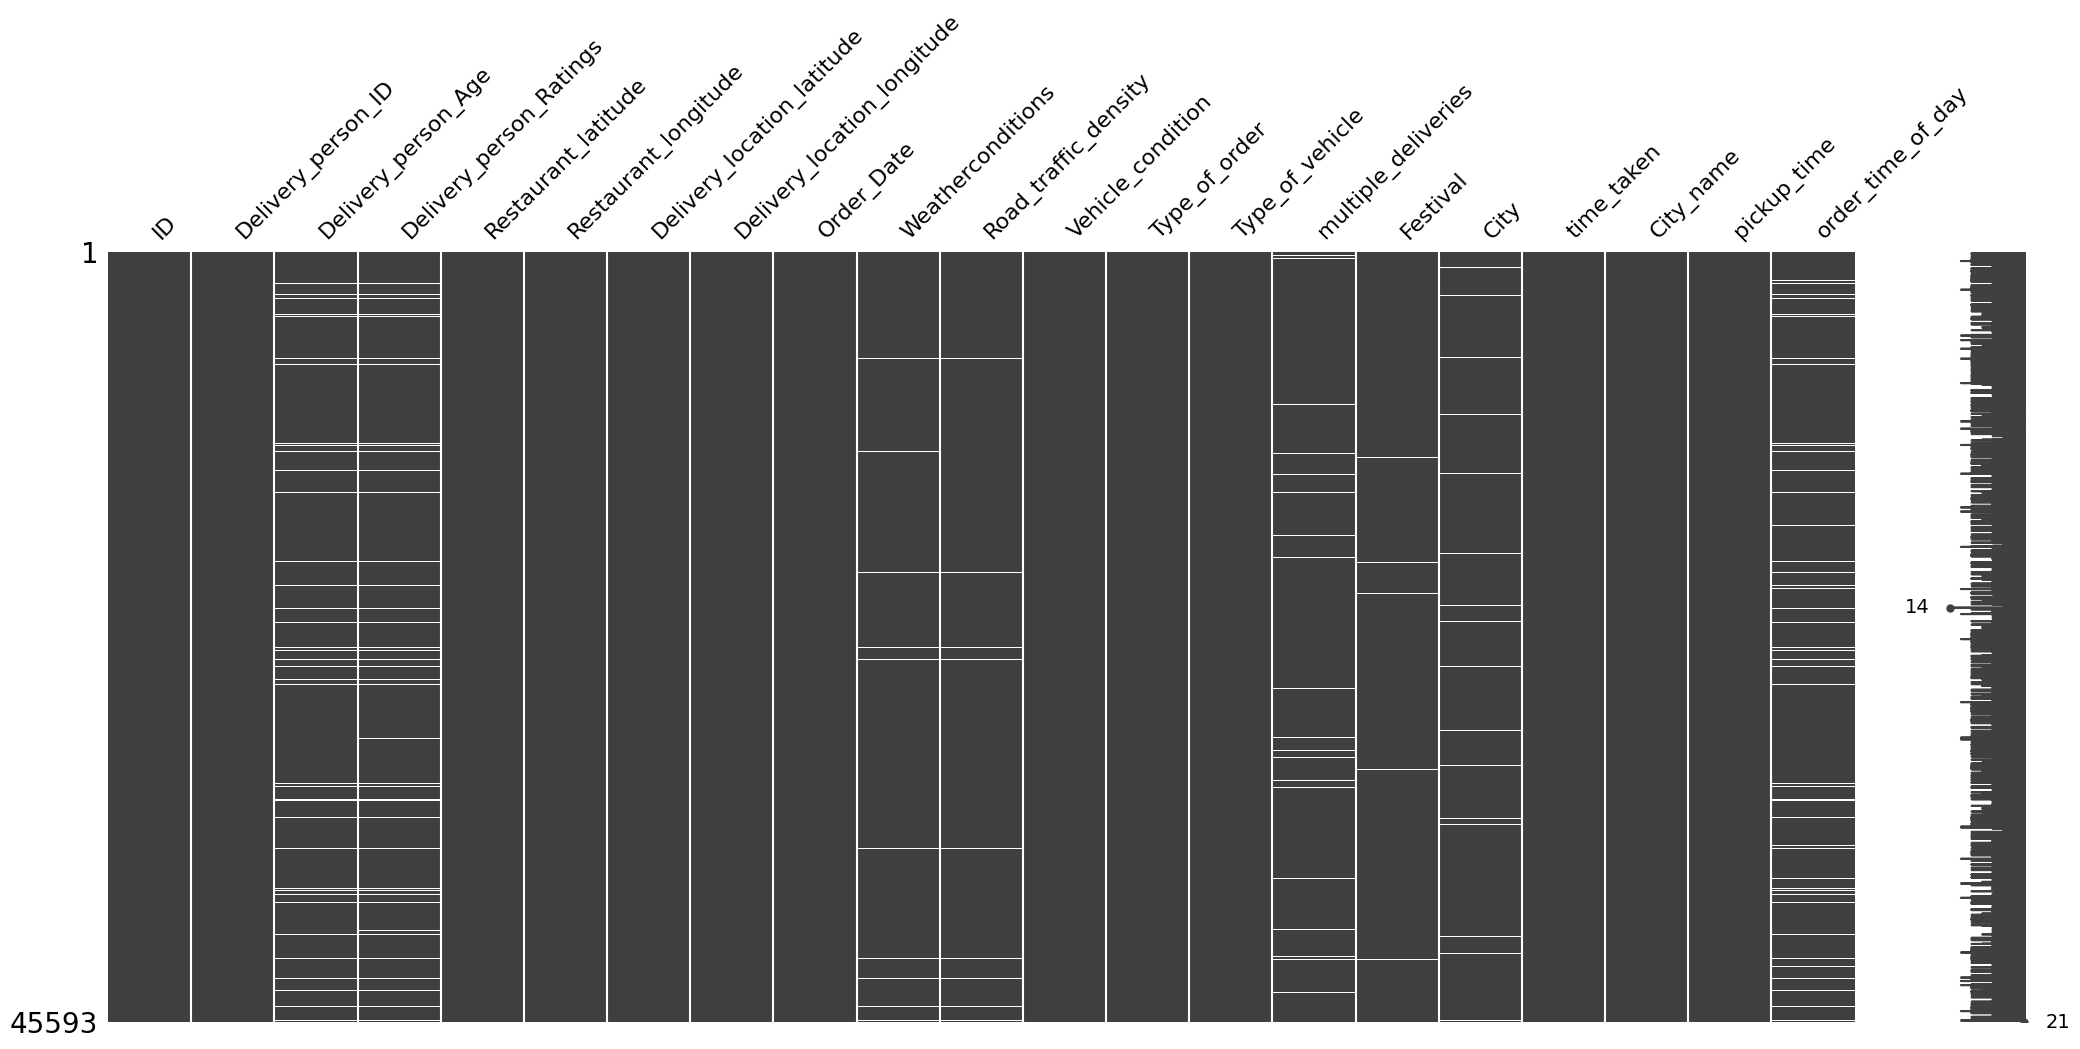

In [61]:
msno.matrix(df)

In [62]:
# we can see the missingness in Delivery person age, delivery person ratings is quite related , also road traffic density and weather condition is related

<Axes: >

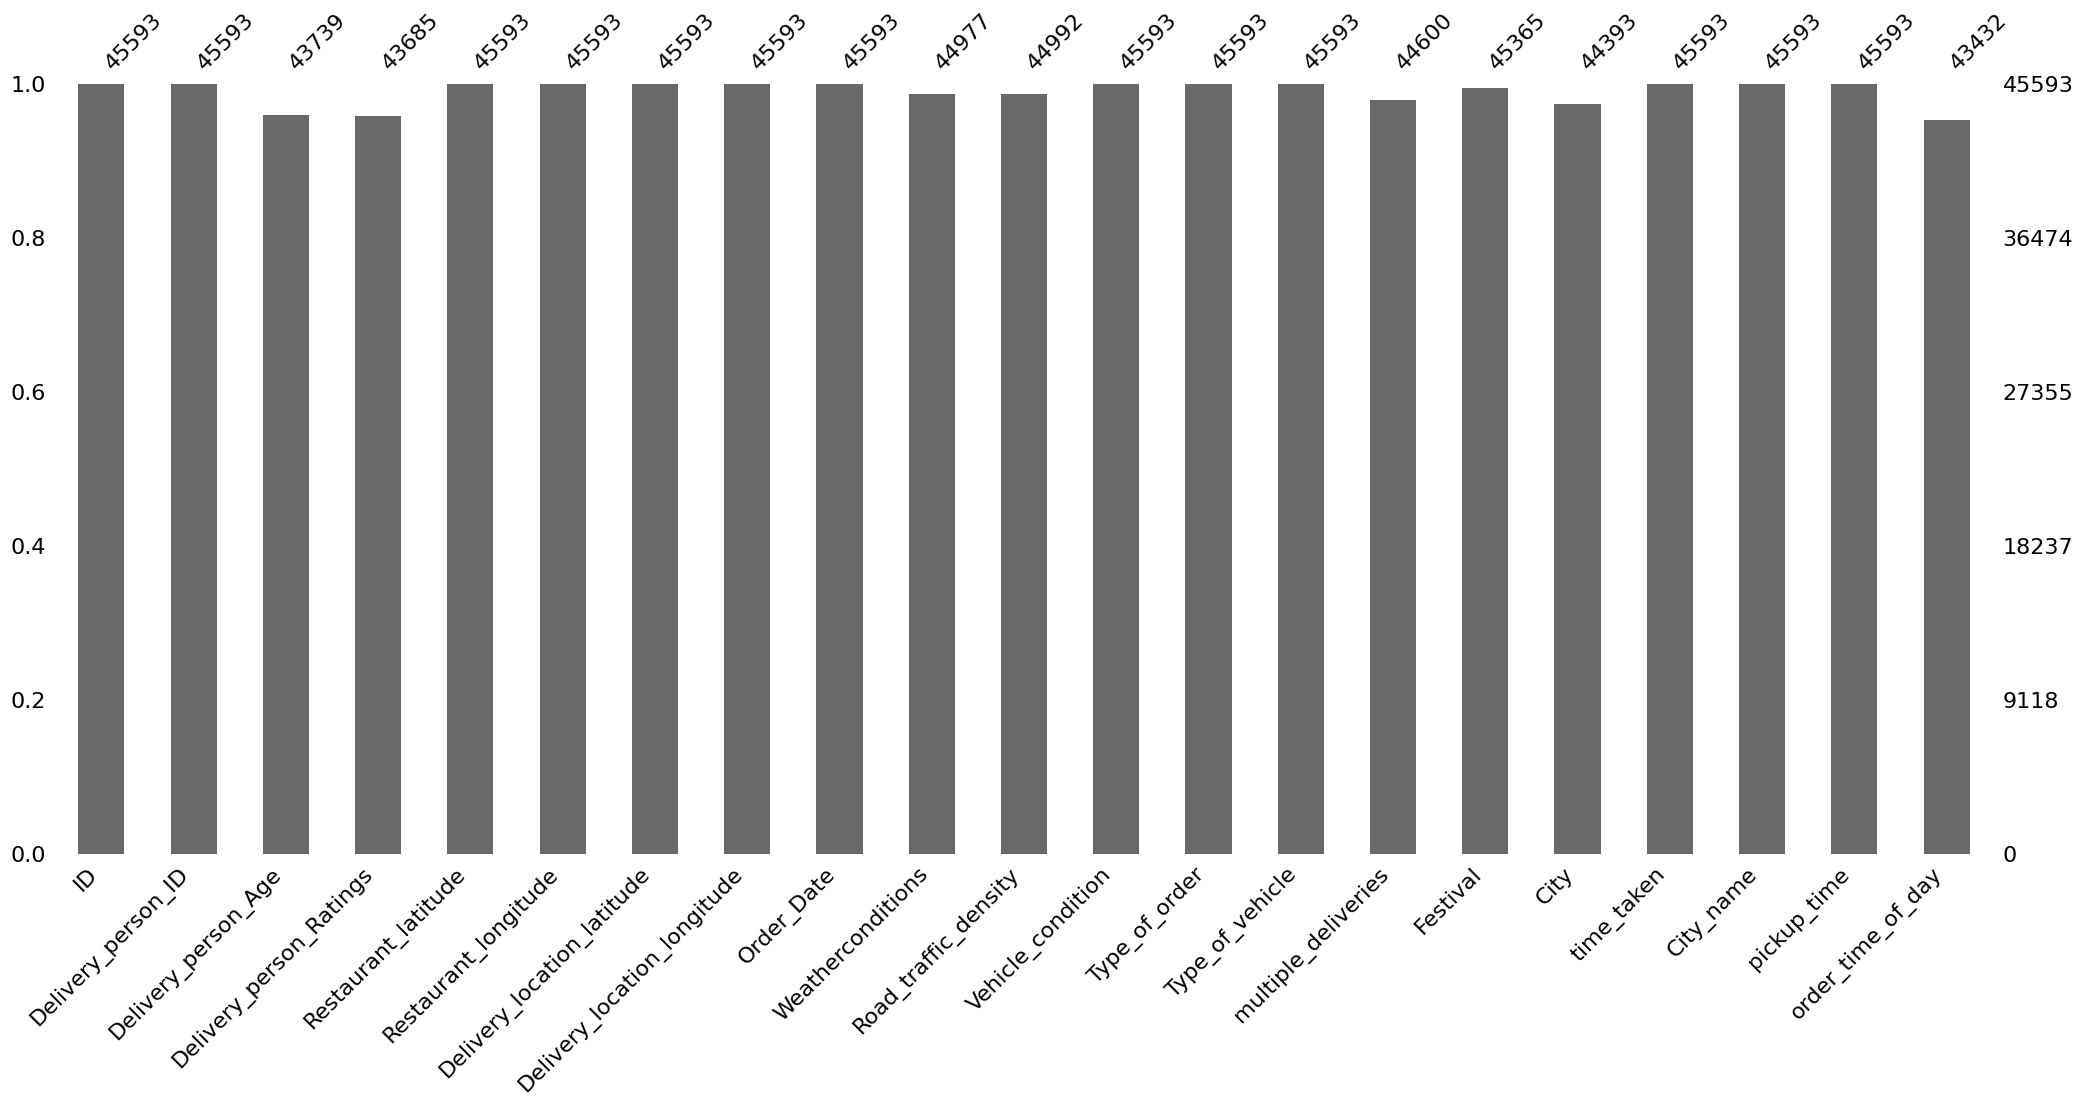

In [63]:
msno.bar(df) # available non ull values in each column

<Axes: >

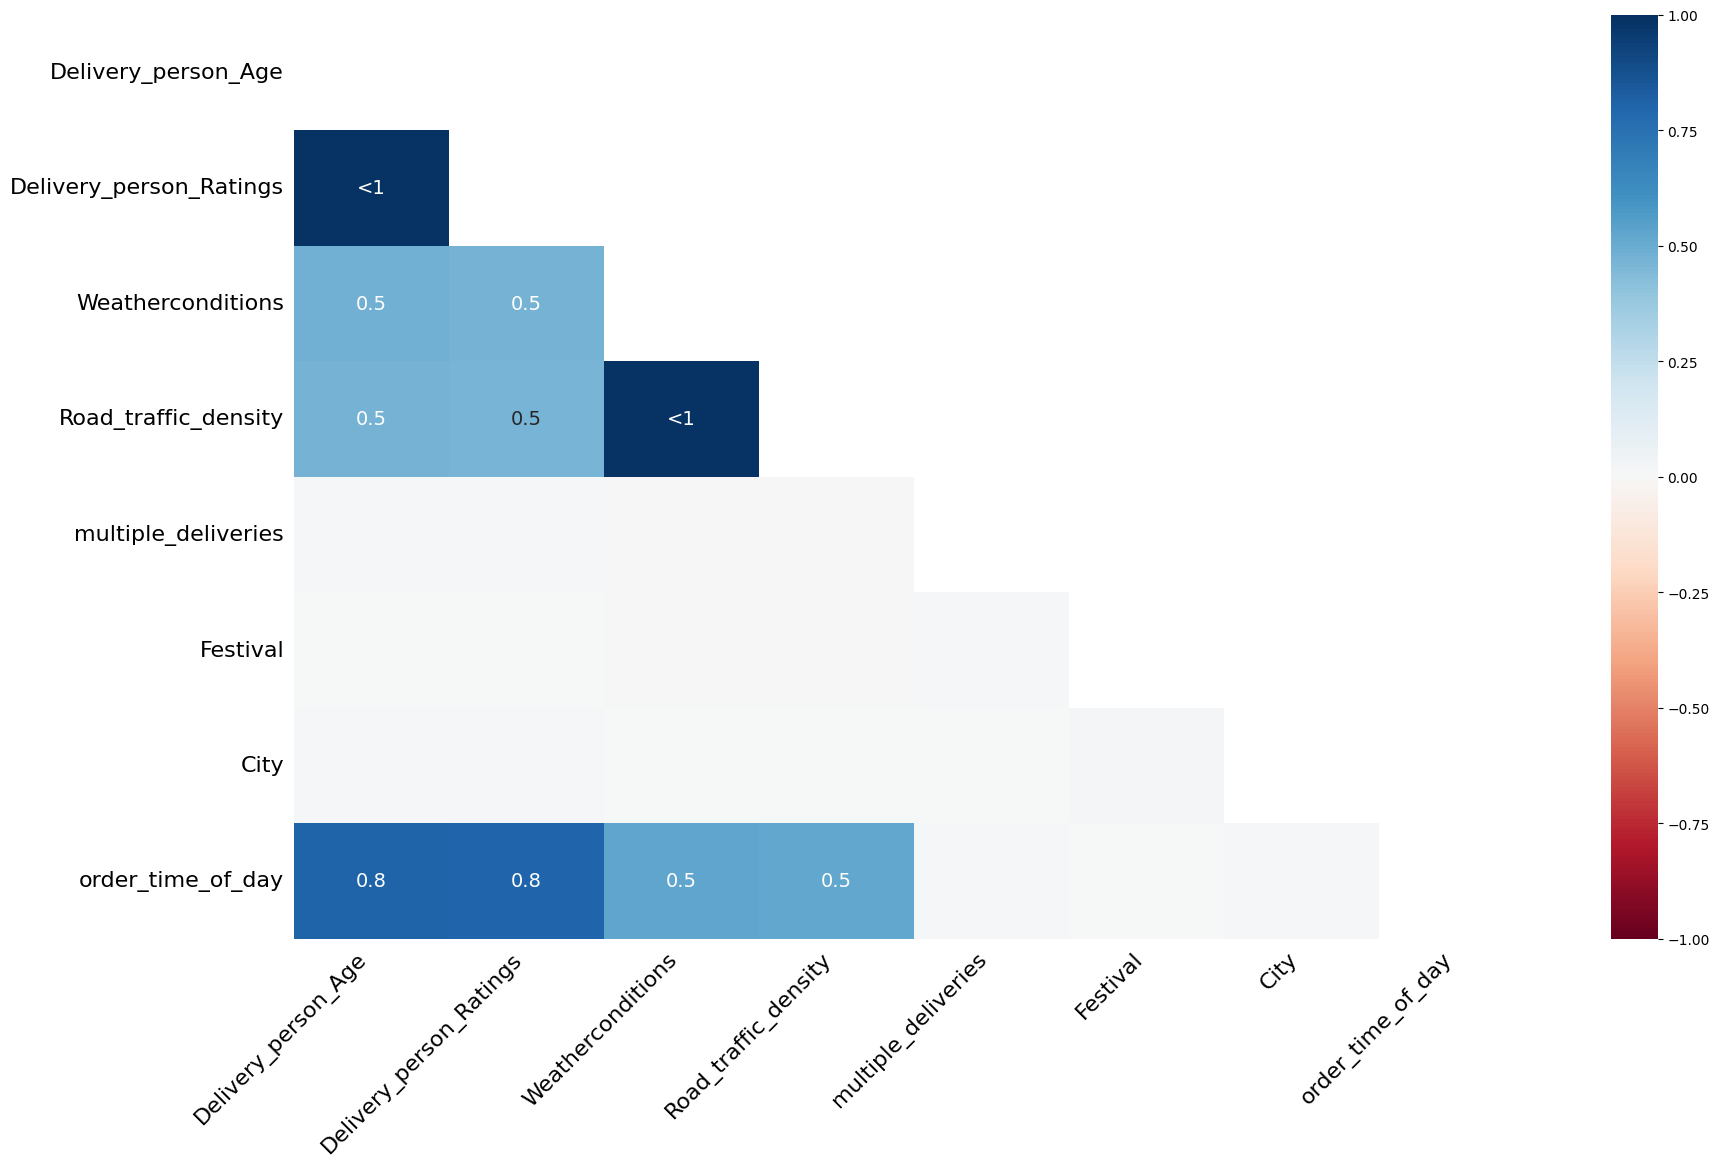

In [64]:
msno.heatmap(df) # shows the correlatiom of missing values

In [65]:
(df[['Weatherconditions','Road_traffic_density']].isna().all(axis=1).sum())/df[['Weatherconditions','Road_traffic_density']].isna().sum()

Weatherconditions       0.975649
Road_traffic_density    1.000000
dtype: float64

<Axes: >

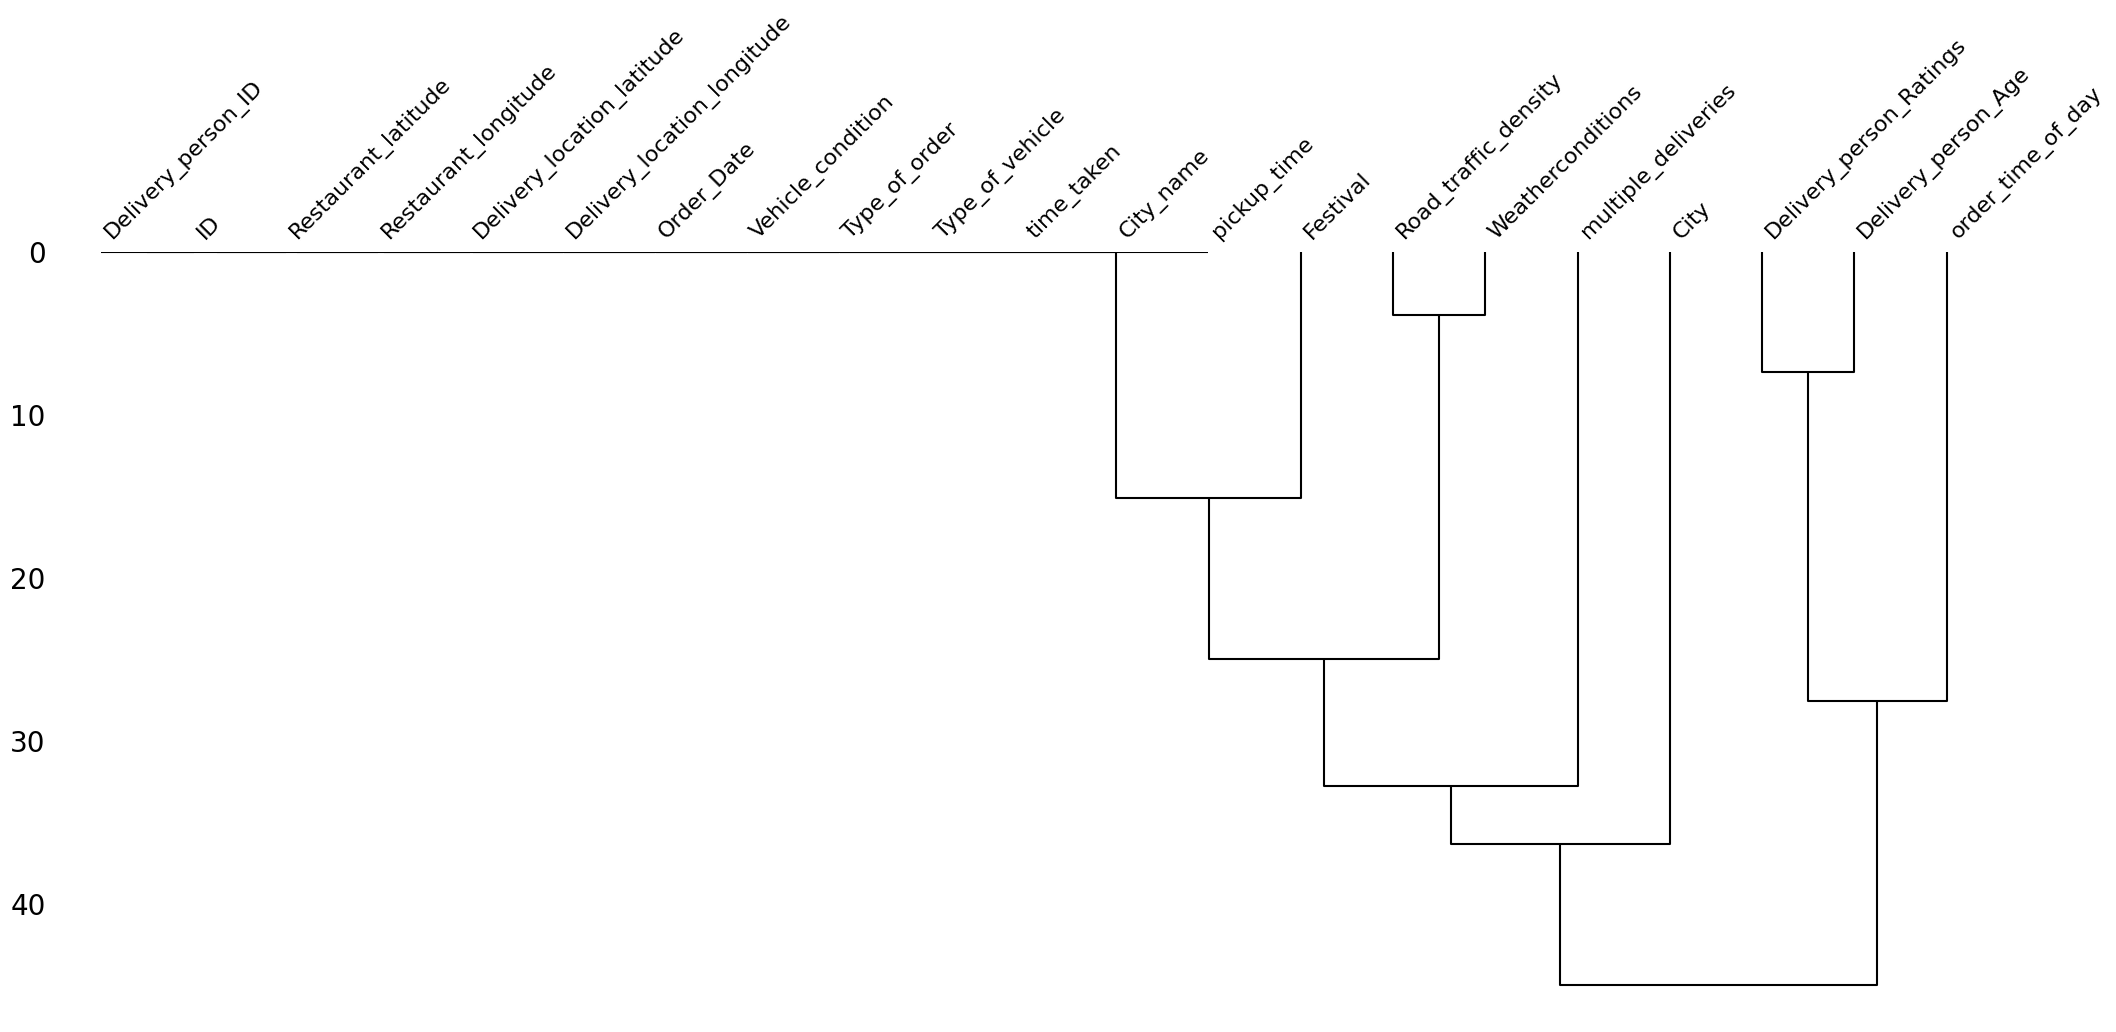

In [66]:
msno.dendrogram(df)

In [67]:
# percentage of rows in the data have missing values
df.isna().any(axis=1).sum()/df.shape[0]*100

10.150681025596034

In [68]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
       'time_taken', 'City_name', 'pickup_time', 'order_time_of_day'],
      dtype='object')

In [69]:
# no of duplicates
df[['ID','Delivery_person_ID']].duplicated().sum()

0

In [70]:
df.Delivery_person_ID.duplicated().sum()

44273

In [71]:
df.loc[df[df.Delivery_person_Age=='NaN '].index , 'Delivery_person_Age']=np.nan

In [72]:
df['Delivery_person_Age']=df.Delivery_person_Age.astype(float)

In [73]:
df['Delivery_person_Age'].describe()

count    43739.000000
mean        29.567137
std          5.815155
min         15.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         50.000000
Name: Delivery_person_Age, dtype: float64

In [74]:
# but 15 min age is not legal so its concerning

<Axes: ylabel='Delivery_person_Age'>

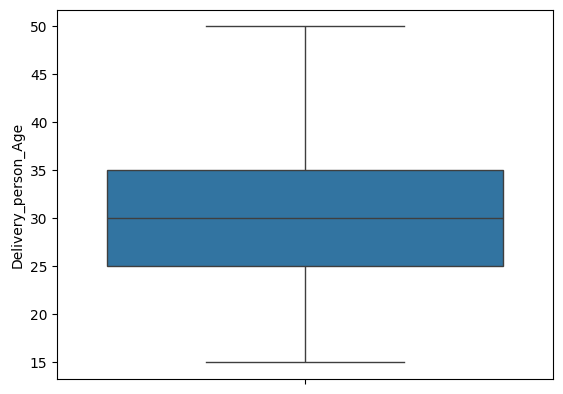

In [75]:
sns.boxplot(df.Delivery_person_Age)

In [76]:
minors_data = df[df.Delivery_person_Age <18]
minors_data

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Weatherconditions,...,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,time_taken,City_name,pickup_time,order_time_of_day
2387,0x564,JAPRES15DEL03,15.0,1.0,-26.891191,75.802083,26.981191,75.892083,12-03-2022,NaN,...,3,Meal,motorcycle,0,No,Urban,(min) 15,Jaipur,0,NaN
2905,0xcd0,INDORES010DEL03,15.0,1.0,22.750040,75.902847,22.810040,75.962847,03-04-2022,NaN,...,3,Snack,scooter,1,No,Metropolitian,(min) 29,Indore,0,NaN
2951,0x91a,SURRES17DEL03,15.0,1.0,21.149569,72.772697,21.209569,72.832697,21-03-2022,NaN,...,3,Buffet,bicycle,1,No,Metropolitian,(min) 20,Surat,0,NaN
5902,0x474,CHENRES15DEL03,15.0,1.0,13.026286,80.275235,13.056286,80.305235,11-03-2022,NaN,...,3,Drinks,bicycle,1,No,Metropolitian,(min) 25,Chennai,0,NaN
9156,0x73f,BANGRES05DEL01,15.0,1.0,12.970324,77.645748,13.080324,77.755748,25-03-2022,NaN,...,3,Buffet,motorcycle,2,No,Metropolitian,(min) 34,Bangalore,0,NaN
10900,0x1b49,MUMRES14DEL02,15.0,1.0,19.181300,72.836191,19.231300,72.886191,30-03-2022,NaN,...,3,Buffet,motorcycle,1,No,Metropolitian,(min) 39,Mumbai,0,NaN
11125,0x40b,SURRES12DEL01,15.0,1.0,-21.183434,-72.814492,21.193434,72.824492,05-03-2022,NaN,...,3,Meal,scooter,1,No,Urban,(min) 27,Surat,0,NaN
12093,0x523,INDORES03DEL02,15.0,1.0,22.751857,75.866699,22.801857,75.916699,24-03-2022,NaN,...,3,Buffet,bicycle,0,No,Metropolitian,(min) 28,Indore,0,NaN
15124,0x18b0,RANCHIRES02DEL01,15.0,1.0,0.000000,0.000000,0.070000,0.070000,16-03-2022,NaN,...,3,Meal,bicycle,1,No,Metropolitian,(min) 21,Ranchi,0,NaN
15927,0x550,CHENRES08DEL02,15.0,1.0,13.022394,80.242439,13.072394,80.292439,11-03-2022,NaN,...,3,Snack,bicycle,0,No,Metropolitian,(min) 17,Chennai,0,NaN


In [77]:
len(minors_data) # here all the ratings of minor riders are 1 , lot of mssing info in Weatherconditions and Road_traffic_density also the pickup time has 0 values denoting missing infomation so we drop it , even some longitude and latitude values are 0 ad negative amd as india is above equator it cant be 0 or negative

38

In [78]:
df.drop(df[df.Delivery_person_Age < 18].index ,inplace=True)

In [79]:
df.Delivery_person_Ratings.describe()

count    43647.000000
mean         4.636944
std          0.317217
min          2.500000
25%          4.500000
50%          4.700000
75%          4.900000
max          6.000000
Name: Delivery_person_Ratings, dtype: float64

In [80]:
df[df.Delivery_person_Ratings>5] # we know for our the rating should be b/w 0-5 , but we have a rating of 6 which has lot of missing info in weather , road_traffic and pickup timealso all missig so we drop this values

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Weatherconditions,...,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,time_taken,City_name,pickup_time,order_time_of_day
3586,0x46d,BANGRES05DEL01,50.0,6.0,-12.970324,-77.645748,13.010324,77.685748,13-03-2022,NaN,...,3,Meal,electric_scooter,0,No,Urban,(min) 25,Bangalore,0,NaN
4714,0x493,HYDRES17DEL01,50.0,6.0,-17.451976,-78.385883,17.561976,78.495883,04-04-2022,NaN,...,3,Snack,bicycle,0,No,Metropolitian,(min) 27,Hyderabad,0,NaN
5169,0x4f2,JAPRES08DEL01,50.0,6.0,-26.910262,-75.783013,27.020262,75.893013,18-03-2022,NaN,...,3,Drinks,scooter,1,No,Metropolitian,(min) 20,Jaipur,0,NaN
5362,0x430,BANGRES19DEL01,50.0,6.0,12.914264,77.678400,13.024264,77.788400,06-04-2022,NaN,...,3,Meal,electric_scooter,1,No,Metropolitian,(min) 18,Bangalore,0,NaN
5651,0xbef1,AGRRES13DEL02,50.0,6.0,-27.159795,-78.042990,27.209795,78.092990,13-02-2022,NaN,...,3,Drinks,scooter,1,No,Metropolitian,(min) 20,Agra,0,NaN
6394,0x427,JAPRES06DEL02,50.0,6.0,26.911927,75.797282,27.041927,75.927282,02-04-2022,NaN,...,3,Meal,electric_scooter,0,No,Urban,(min) 20,Jaipur,0,NaN
7031,0x3eb,MYSRES15DEL02,50.0,6.0,-12.352058,-76.606650,12.372058,76.626650,15-03-2022,NaN,...,3,Buffet,scooter,1,No,Metropolitian,(min) 14,Mysore,0,NaN
7681,0xd42,VADRES09DEL01,50.0,6.0,0.000000,0.000000,0.010000,0.010000,21-03-2022,NaN,...,3,Meal,bicycle,1,No,Metropolitian,(min) 22,Vadodara,0,NaN
9499,0x3f0,BANGRES010DEL01,50.0,6.0,12.933298,77.614293,13.003298,77.684293,12-03-2022,NaN,...,3,Drinks,scooter,1,No,Urban,(min) 17,Bangalore,0,NaN
9535,0x3ef,RANCHIRES13DEL01,50.0,6.0,-23.374989,-85.335486,23.444989,85.405486,20-03-2022,NaN,...,3,Snack,bicycle,1,No,Metropolitian,(min) 32,Ranchi,0,NaN


In [81]:
df.drop(df[df.Delivery_person_Ratings>5].index,inplace=True)

In [82]:
locatio_columns = df.iloc[:,4:8]

In [83]:
locatio_columns.describe()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
count,45502.000000,45502.000000,45502.000000,45502.000000
mean,17.046293,70.326557,17.468434,70.848718
std,8.131457,22.591753,7.334058,21.111306
min,-30.905562,-88.352885,0.010000,0.010000
25%,12.933284,73.170283,12.988453,73.280000
50%,18.551440,75.898497,18.634382,76.002471
75%,22.728163,78.045043,22.785049,78.105359
max,30.914057,88.433452,31.054057,88.563452


 India lies to the north of the equator b/w 6'44 and 35'30 north latitude and  68'7 and 97'25 east longitude

In [84]:
lower_lat = 6.44
upper_lat = 35.30
lower_long = 68.7
upper_long = 97.25

In [85]:
outer_lat_rest_index = df[(df.Restaurant_latitude<6.44)|(df.Restaurant_latitude > 35.30)].index

In [86]:
 outer_long_rest_index = df[(df.Restaurant_longitude<68.7)|(df.Restaurant_longitude > 97.25)].index

In [87]:
outer_lat_rest_index

Index([   33,    52,    57,    59,    67,    68,    72,    73,    76,    81,
       ...
       45514, 45531, 45536, 45543, 45547, 45569, 45576, 45577, 45579, 45589],
      dtype='int64', length=4029)

In [88]:
outer_long_rest_index

Index([   33,    52,    57,    59,    67,    68,    72,    73,    76,    81,
       ...
       45514, 45531, 45536, 45543, 45547, 45569, 45576, 45577, 45579, 45589],
      dtype='int64', length=3765)

In [89]:
matched_rest_index = []
for i in outer_lat_rest_index:
    for j in outer_long_rest_index:
            if i==j:
                matched_rest_index.append(i)

In [90]:
len(matched_rest_index)  # so all the langitude index matches where latitude is either greater than the upper bound or lower than the lower bound

3765

In [91]:
outer_lat_deliv_index = df[(df.Delivery_location_latitude<6.44)|(df.Delivery_location_latitude > 35.30)].index
outer_long_deliv_index = df[(df.Delivery_location_longitude<68.7)|(df.Delivery_location_longitude > 97.25)].index

In [92]:
outer_lat_deliv_index

Index([   33,    52,    57,    59,    67,    68,    72,    73,    76,    81,
       ...
       45514, 45531, 45536, 45543, 45547, 45569, 45576, 45577, 45579, 45589],
      dtype='int64', length=3630)

In [93]:
outer_long_deliv_index

Index([   33,    52,    57,    59,    67,    68,    72,    73,    76,    81,
       ...
       45514, 45531, 45536, 45543, 45547, 45569, 45576, 45577, 45579, 45589],
      dtype='int64', length=3630)

In [94]:
matched_deliv_index = []
for i in outer_lat_deliv_index:
    for j in outer_long_deliv_index:
            if i==j:
                matched_deliv_index.append(i)

In [95]:
len(matched_deliv_index)  # so we see in delivery_location the latitude and longitude is both out of bounds together

3630

In [96]:
locatio_columns[(df.Restaurant_latitude<6.44)|(df.Restaurant_latitude > 35.30)|(df.Restaurant_longitude<68.7)|(df.Restaurant_longitude > 97.25)|(df.Delivery_location_latitude<6.44)|(df.Delivery_location_latitude > 35.30)|(df.Delivery_location_longitude<68.7)|(df.Delivery_location_longitude > 97.25)].describe()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
count,4029.000000,4029.000000,4029.000000,4029.000000
mean,-2.024551,2.522899,2.087684,7.764720
std,6.385871,24.383056,6.386195,23.271934
min,-30.905562,-88.352885,0.010000,0.010000
25%,0.000000,0.000000,0.040000,0.040000
50%,0.000000,0.000000,0.070000,0.070000
75%,0.000000,0.000000,0.110000,0.110000
max,0.000000,88.433452,31.045562,88.523452


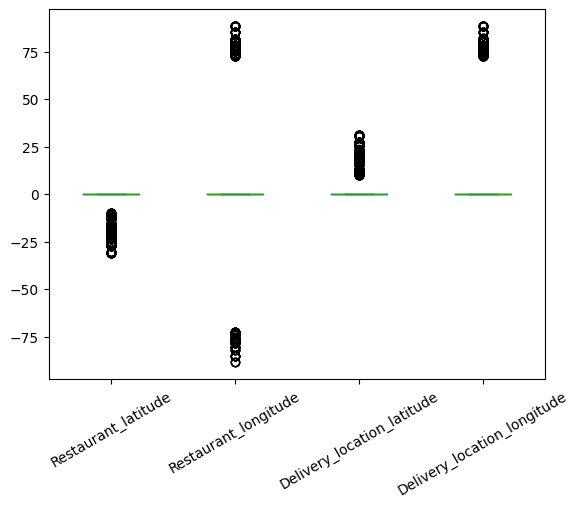

In [97]:
# boxplot for all anomalies
locatio_columns[(df.Restaurant_latitude<6.44)|(df.Restaurant_latitude > 35.30)|(df.Restaurant_longitude<68.7)|(df.Restaurant_longitude > 97.25)|(df.Delivery_location_latitude<6.44)|(df.Delivery_location_latitude > 35.30)|(df.Delivery_location_longitude<68.7)|(df.Delivery_location_longitude > 97.25)].plot(kind='box')
plt.xticks(rotation=30);

In [98]:
# one error here in date is the latitude and longitude are correct but they are misplaced as negative so if we take absolute of it , we can fix it

In [99]:
df[['Restaurant_latitude','Restaurant_longitude']]=abs(df[['Restaurant_latitude','Restaurant_longitude']]) # since only restaurant long and lati has negative values , 0 values we can further impute later

In [100]:
# lets check for more anomalies after converting thr negative to positive 
locatio_columns[(df.Restaurant_latitude<6.44)|(df.Restaurant_latitude > 35.30)|(df.Restaurant_longitude<68.7)|(df.Restaurant_longitude > 97.25)|(df.Delivery_location_latitude<6.44)|(df.Delivery_location_latitude > 35.30)|(df.Delivery_location_longitude<68.7)|(df.Delivery_location_longitude > 97.25)].describe()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
count,3630.0,3630.0,3630.000000,3630.000000
mean,0.0,0.0,0.063041,0.063041
std,0.0,0.0,0.036055,0.036055
min,0.0,0.0,0.010000,0.010000
25%,0.0,0.0,0.030000,0.030000
50%,0.0,0.0,0.060000,0.060000
75%,0.0,0.0,0.090000,0.090000
max,0.0,0.0,0.130000,0.130000


In [101]:
len(locatio_columns[(df.Restaurant_latitude<6.44)|(df.Restaurant_latitude > 35.30)|(df.Restaurant_longitude<68.7)|(df.Restaurant_longitude > 97.25)|(df.Delivery_location_latitude<6.44)|(df.Delivery_location_latitude > 35.30)|(df.Delivery_location_longitude<68.7)|(df.Delivery_location_longitude > 97.25)])

3630

In [102]:
# from here we see restaurant latitde and longi is affected by 0 values only , but in deliver_lat and delibery_long they dont have 0 value but they are affected by the lower bound , all are below the lower bound and no values above upper bound

In [103]:
locatio_columns[(df.Restaurant_latitude<1)|(df.Restaurant_longitude<1)|(df.Delivery_location_latitude<1)|(df.Delivery_location_longitude<1)].describe()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
count,3630.0,3630.0,3630.000000,3630.000000
mean,0.0,0.0,0.063041,0.063041
std,0.0,0.0,0.036055,0.036055
min,0.0,0.0,0.010000,0.010000
25%,0.0,0.0,0.030000,0.030000
50%,0.0,0.0,0.060000,0.060000
75%,0.0,0.0,0.090000,0.090000
max,0.0,0.0,0.130000,0.130000


In [104]:
zero_values = locatio_columns[(df.Restaurant_latitude<1)|(df.Restaurant_longitude<1)|(df.Delivery_location_latitude<1)|(df.Delivery_location_longitude<1)].index

In [105]:
locatio_columns.columns

Index(['Restaurant_latitude', 'Restaurant_longitude',
       'Delivery_location_latitude', 'Delivery_location_longitude'],
      dtype='object')

In [106]:
df.loc[zero_values,locatio_columns.columns]=np.nan

In [107]:
df.isna().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude            3630
Restaurant_longitude           3630
Delivery_location_latitude     3630
Delivery_location_longitude    3630
Order_Date                        0
Weatherconditions               525
Road_traffic_density            510
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1198
time_taken                        0
City_name                         0
pickup_time                       0
order_time_of_day              2070
dtype: int64

In [108]:
df['Order_Date']= pd.to_datetime(df.Order_Date)

In [109]:
df.Order_Date

0       2022-03-19
1       2022-03-25
2       2022-03-19
3       2022-04-05
4       2022-03-26
           ...    
45588   2022-03-24
45589   2022-02-16
45590   2022-03-11
45591   2022-03-07
45592   2022-03-02
Name: Order_Date, Length: 45502, dtype: datetime64[ns]

In [110]:
df['Day']= df.Order_Date.dt.day
df['Month']=df.Order_Date.dt.month
df['Year']=df.Order_Date.dt.year
df['is_weekend']= df.Order_Date.dt.day_name().apply(lambda x:1 if x in ('Saturday','Sunday') else 0)

In [111]:
df.sample(20)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Weatherconditions,...,Festival,City,time_taken,City_name,pickup_time,order_time_of_day,Day,Month,Year,is_weekend
973,0x401,BANGRES20DEL03,NaN,NaN,12.972161,77.596014,13.062161,77.686014,2022-03-10,NaN,...,No,Metropolitian,(min) 14,Bangalore,0,NaN,10,3,2022,0
10252,0x6135,JAPRES11DEL03,36.0,4.1,26.902940,75.793007,26.992940,75.883007,2022-04-04,Stormy,...,Yes,Metropolitian,(min) 43,Jaipur,5,Night,4,4,2022,0
10075,0xaf97,JAPRES18DEL02,37.0,4.6,26.913987,75.752891,27.043987,75.882891,2022-03-18,Sandstorms,...,No,Urban,(min) 19,Jaipur,5,Night,18,3,2022,0
18807,0x5963,MUMRES14DEL02,21.0,4.9,19.181300,72.836191,19.311300,72.966191,2022-03-23,Sunny,...,No,Urban,(min) 22,Mumbai,15,Night,23,3,2022,0
33691,0xbd16,MYSRES02DEL03,35.0,4.7,12.304569,76.643622,12.364569,76.703622,2022-03-17,Cloudy,...,No,Urban,(min) 26,Mysore,5,Evening,17,3,2022,0
656,0x8e3,SURRES010DEL03,NaN,NaN,21.171060,72.789292,21.231060,72.849292,2022-03-09,Fog,...,No,Metropolitian,(min) 21,Surat,0,NaN,9,3,2022,0
26312,0xd422,KOLRES06DEL03,24.0,4.2,22.533662,88.366217,22.563662,88.396217,2022-02-17,Stormy,...,No,Urban,(min) 25,Kolkata,5,Night,17,2,2022,0
15325,0x107f,MUMRES17DEL02,NaN,NaN,19.121999,72.908493,19.201999,72.988493,2022-03-02,Windy,...,No,Metropolitian,(min) 29,Mumbai,0,NaN,2,3,2022,0
24973,0x93d3,HYDRES19DEL02,32.0,4.7,17.458998,78.500366,17.508998,78.550366,2022-04-01,Windy,...,No,Metropolitian,(min) 26,Hyderabad,10,Evening,1,4,2022,0
31513,0x9efb,JAPRES15DEL03,26.0,5.0,26.891191,75.802083,26.981191,75.892083,2022-03-02,Windy,...,No,Metropolitian,(min) 14,Jaipur,5,Night,2,3,2022,0


In [112]:
df.Weatherconditions.unique()

array(['Sunny', 'Stormy', 'Sandstorms', 'Cloudy', 'Fog', 'Windy', nan],
      dtype=object)

In [113]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
       'time_taken', 'City_name', 'pickup_time', 'order_time_of_day', 'Day',
       'Month', 'Year', 'is_weekend'],
      dtype='object')

In [114]:
df.Road_traffic_density.unique()

array(['High ', 'Jam ', 'Low ', 'Medium ', nan], dtype=object)

In [115]:
df.Type_of_order.unique()

array(['Snack', 'Drinks', 'Buffet', 'Meal'], dtype=object)

In [116]:
cols = ['Road_traffic_density','Type_of_order','City']
for i in cols:
    df[i]=df[i].str.strip().str.lower()

In [117]:
df.City.unique()

array(['urban', 'metropolitian', 'semi-urban', nan], dtype=object)

In [118]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
       'time_taken', 'City_name', 'pickup_time', 'order_time_of_day', 'Day',
       'Month', 'Year', 'is_weekend'],
      dtype='object')

In [119]:
df.time_taken

0        (min) 24
1        (min) 33
2        (min) 26
3        (min) 21
4        (min) 30
           ...   
45588    (min) 32
45589    (min) 36
45590    (min) 16
45591    (min) 26
45592    (min) 36
Name: time_taken, Length: 45502, dtype: object

In [120]:
df['time_taken']=df['time_taken'].str.split(' ').str[1].astype(int)

In [121]:
df.sample(20)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Weatherconditions,...,Festival,City,time_taken,City_name,pickup_time,order_time_of_day,Day,Month,Year,is_weekend
17392,0x1191,MUMRES08DEL01,24.0,4.9,19.065838,72.832658,19.075838,72.842658,2022-03-30,Sunny,...,No,metropolitian,18,Mumbai,5,Morning,30,3,2022,0
34681,0x9c77,JAPRES08DEL03,21.0,4.7,26.910262,75.783013,26.940262,75.813013,2022-03-15,Cloudy,...,No,metropolitian,21,Jaipur,10,Night,15,3,2022,0
24998,0x8434,RANCHIRES16DEL01,20.0,4.9,23.371292,85.327872,23.481292,85.437872,2022-03-12,Fog,...,No,metropolitian,24,Ranchi,15,Night,12,3,2022,1
35185,0x9304,PUNERES14DEL02,34.0,4.7,18.516216,73.842527,18.646216,73.972527,2022-03-18,Stormy,...,No,metropolitian,28,Pune,15,Night,18,3,2022,0
41486,0x8d1f,INDORES15DEL01,39.0,4.9,22.760072,75.892574,22.830072,75.962574,2022-03-20,Stormy,...,No,metropolitian,25,Indore,5,Night,20,3,2022,1
44649,0xcbbf,ALHRES05DEL03,27.0,4.6,25.457687,81.835585,25.487687,81.865585,2022-02-15,Sunny,...,No,NaN,14,Allahabad,10,Night,15,2,2022,0
37339,0x6bc4,INDORES06DEL01,35.0,5.0,22.728163,75.884212,22.768163,75.924212,2022-04-05,Cloudy,...,No,metropolitian,31,Indore,10,Afternoon,5,4,2022,0
3527,0xb91c,HYDRES08DEL02,25.0,4.5,17.438263,78.397865,17.518263,78.477865,2022-03-25,Stormy,...,No,metropolitian,16,Hyderabad,5,Night,25,3,2022,0
38293,0x3c09,SURRES010DEL01,24.0,4.3,21.171060,72.789292,21.181060,72.799292,2022-03-09,Windy,...,No,metropolitian,26,Surat,15,Morning,9,3,2022,0
31228,0xb4b8,VADRES15DEL01,35.0,4.9,NaN,NaN,NaN,NaN,2022-03-04,Windy,...,No,metropolitian,38,Vadodara,5,Evening,4,3,2022,0


In [122]:
# now to calculate distance b/w lattitude and longitude points , to find distance we use the haversine formula
locatio_columns = df.iloc[:,4:8]

In [123]:
lat_0 = np.radians(locatio_columns.iloc[:,0])
lat_1 = np.radians(locatio_columns.iloc[:,2])
long_0 = np.radians(locatio_columns.iloc[:,1])
long_1 = np.radians(locatio_columns.iloc[:,3])

d = 6378.8*np.arccos(((np.sin(lat_0)*np.sin(lat_1))+(np.cos(lat_0)*np.cos(lat_1)*np.cos(long_1-long_0))))

In [124]:
df['Distance']=d

In [125]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
       'time_taken', 'City_name', 'pickup_time', 'order_time_of_day', 'Day',
       'Month', 'Year', 'is_weekend', 'Distance'],
      dtype='object')

In [126]:
df.isna().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude            3630
Restaurant_longitude           3630
Delivery_location_latitude     3630
Delivery_location_longitude    3630
Order_Date                        0
Weatherconditions               525
Road_traffic_density            510
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1198
time_taken                        0
City_name                         0
pickup_time                       0
order_time_of_day              2070
Day                               0
Month                             0
Year                              0
is_weekend                        0
Distance                       3630
dtype: int64

([0, 1, 2, 3],
 [Text(0, 0, 'Restaurant_latitude'),
  Text(1, 0, 'Restaurant_longitude'),
  Text(2, 0, 'Delivery_location_latitude'),
  Text(3, 0, 'Delivery_location_longitude')])

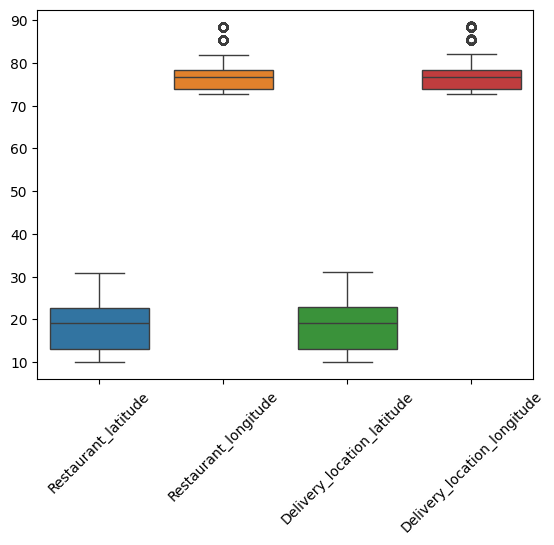

In [127]:
sns.boxplot(locatio_columns)
plt.xticks(rotation=45)

In [128]:
locatio_columns.describe()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
count,41872.000000,41872.000000,41872.000000,41872.000000
mean,18.913696,76.921664,18.977356,76.985325
std,5.467265,3.503107,5.469056,3.503260
min,9.957144,72.768726,9.967144,72.778726
25%,12.986047,73.897902,13.065996,73.940327
50%,19.065838,76.618203,19.124049,76.662620
75%,22.751234,78.368855,22.820040,78.405467
max,30.914057,88.433452,31.054057,88.563452


<Axes: >

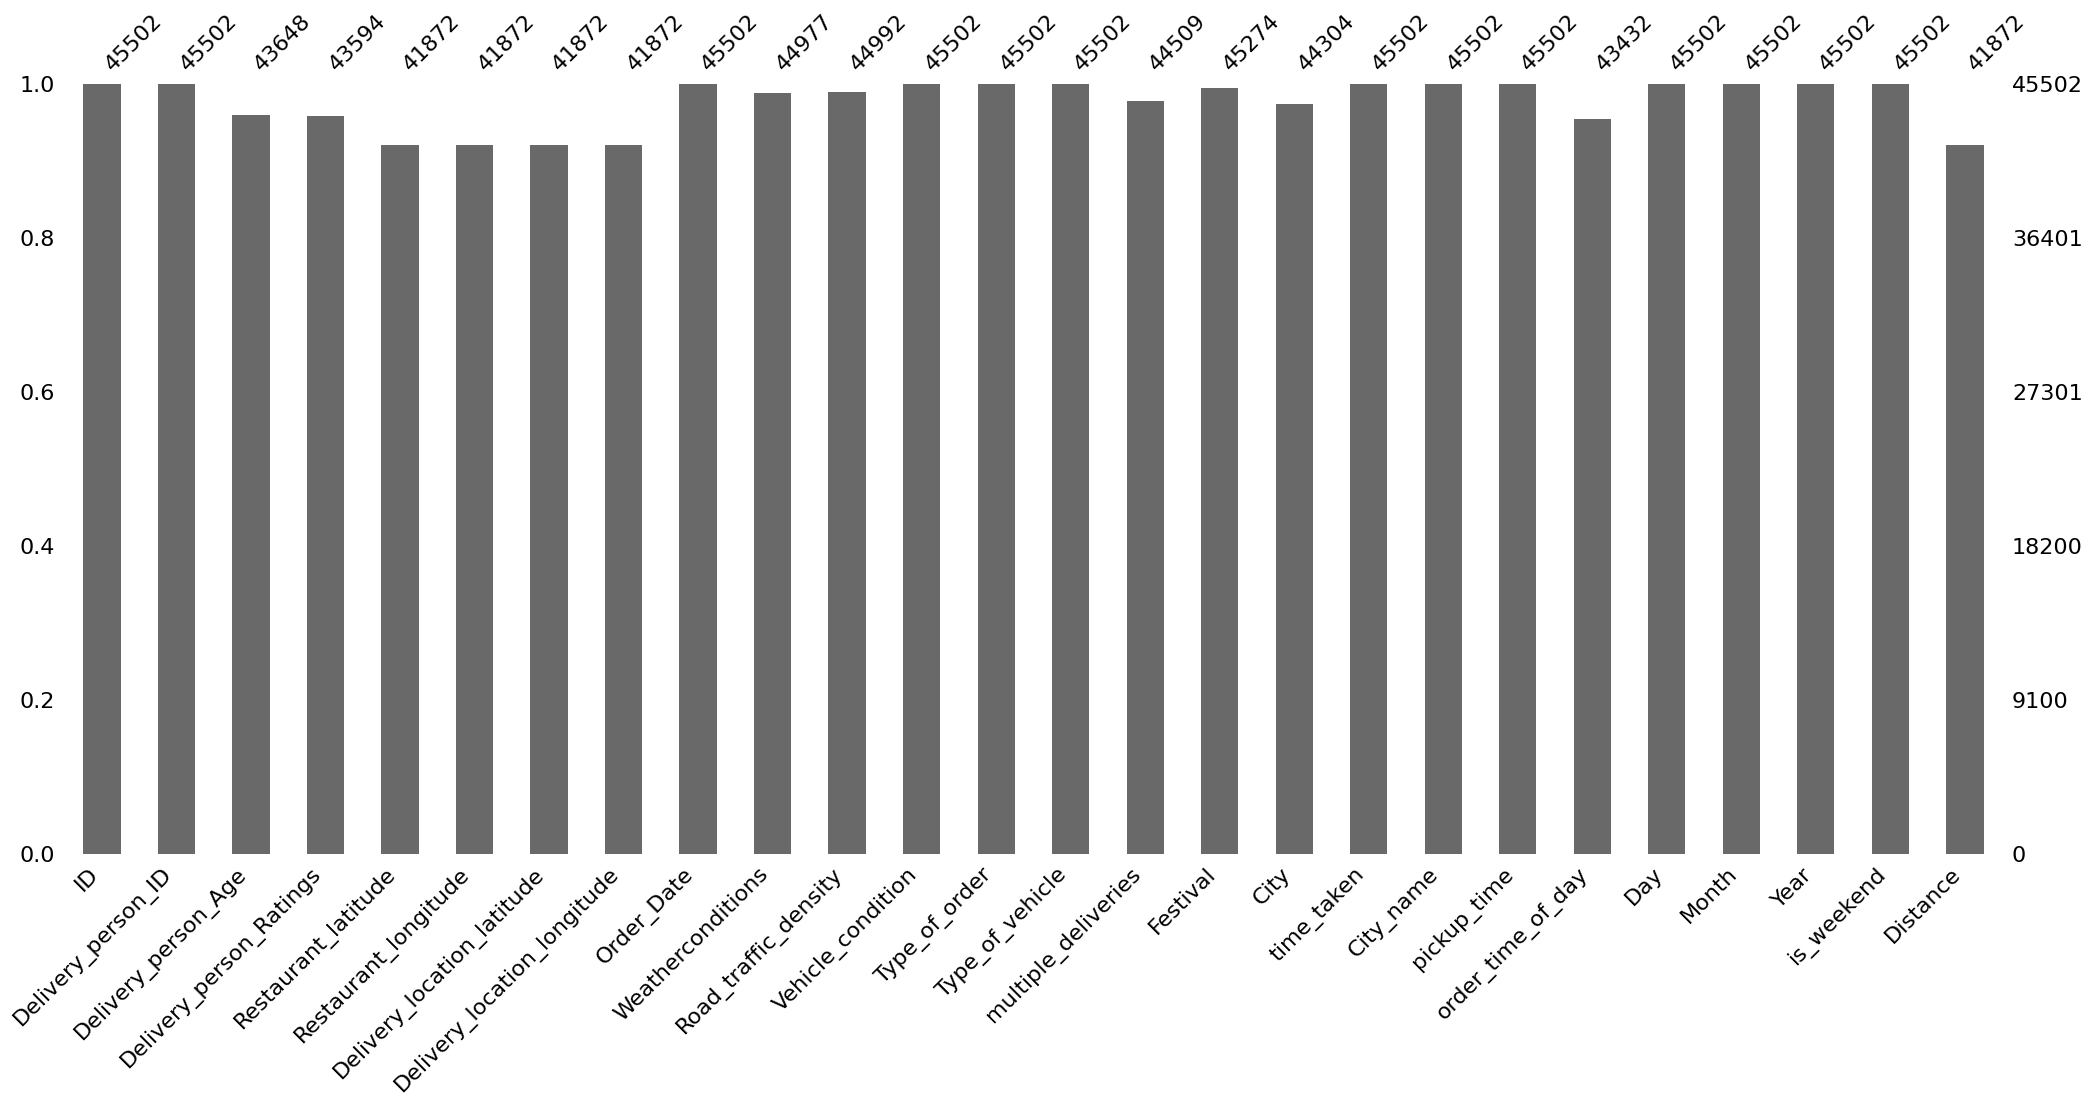

In [129]:
msno.bar(df)

In [130]:
df.isna().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude            3630
Restaurant_longitude           3630
Delivery_location_latitude     3630
Delivery_location_longitude    3630
Order_Date                        0
Weatherconditions               525
Road_traffic_density            510
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1198
time_taken                        0
City_name                         0
pickup_time                       0
order_time_of_day              2070
Day                               0
Month                             0
Year                              0
is_weekend                        0
Distance                       3630
dtype: int64

In [131]:
df.to_csv('cleaned_swiggy',index=False)

In [213]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler, PowerTransformer, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error

In [214]:
# We first perform our model training on our og data without missing value imputation and find the r2 score and then compare the r2 score by traiing our baseline model after imputing missing values

In [215]:
df.sample(20)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Weatherconditions,...,time_taken,City_name,pickup_time,order_time_of_day,Day,Month,Year,is_weekend,Distance,time_taken_pt
19714,0x838,COIMBRES16DEL02,NaN,NaN,11.010375,76.952950,11.060375,77.002950,2022-03-09,Sunny,...,25,Coimbatore,5,Evening,9,3,2022,0,7.799852,-0.019371
15640,0x3534,COIMBRES010DEL01,39.0,4.9,11.003008,76.975440,11.013008,76.985440,2022-03-26,Fog,...,18,Coimbatore,15,Morning,26,3,2022,1,1.560042,-0.869203
26955,0xe02,PUNERES18DEL02,22.0,4.6,18.593481,73.785901,18.643481,73.835901,2022-03-11,Cloudy,...,15,Pune,5,Night,11,3,2022,0,7.669065,-1.301360
42024,0xe117,KNPRES08DEL01,27.0,4.9,NaN,NaN,NaN,NaN,2022-02-16,Sandstorms,...,15,Kanpur,10,Night,16,2,2022,0,NaN,-1.301360
22599,0x403,PUNERES15DEL01,NaN,NaN,18.636215,73.751081,18.746215,73.861081,2022-03-16,NaN,...,37,Pune,0,NaN,16,3,2022,0,16.868522,1.124102
45022,0xb051,CHENRES19DEL03,30.0,4.8,12.986047,80.218114,13.076047,80.308114,2022-03-04,Sunny,...,28,Chennai,5,Night,4,3,2022,0,13.988865,0.296171
2849,0xdedf,KOCRES11DEL01,29.0,5.0,10.006881,76.345397,10.016881,76.355397,2022-02-17,Fog,...,17,Kochi,5,Morning,17,2,2022,0,1.562517,-1.007626
43138,0x3c7f,MYSRES09DEL03,22.0,5.0,12.323194,76.630583,12.383194,76.690583,2022-03-13,Windy,...,21,Mysore,15,Evening,13,3,2022,1,9.338035,-0.482135
8291,0xbdc7,JAPRES02DEL02,27.0,4.2,26.914142,75.805704,26.994142,75.885704,2022-03-25,Cloudy,...,35,Jaipur,10,Evening,25,3,2022,0,11.931165,0.952962
19208,0x7b79,CHENRES16DEL03,29.0,4.8,13.049645,80.242268,13.079645,80.272268,2022-03-03,Windy,...,23,Chennai,15,Evening,3,3,2022,0,4.662647,-0.244054


In [216]:
df['distance_type']=df.Distance.round().apply(lambda x: 'short' if x in range(0,5) else 'medium' if x in range(5,10) else 'long' if x in range(10,15) else 'very long' if x in range(15,25) else np.nan)

In [217]:
df.drop(columns=['ID', 'Delivery_person_ID','Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date' ,'Year','Day'],inplace=True)  # we drop it since a data of 2022 so all year values are 2022 

In [218]:
df.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
       'time_taken', 'City_name', 'pickup_time', 'order_time_of_day', 'Month',
       'is_weekend', 'Distance', 'time_taken_pt', 'distance_type'],
      dtype='object')

In [219]:
df.isna().sum()

Delivery_person_Age        1854
Delivery_person_Ratings    1908
Weatherconditions           525
Road_traffic_density        510
Vehicle_condition             0
Type_of_order                 0
Type_of_vehicle               0
multiple_deliveries         993
Festival                    228
City                       1198
time_taken                    0
City_name                     0
pickup_time                   0
order_time_of_day          2070
Month                         0
is_weekend                    0
Distance                   3630
time_taken_pt                 0
distance_type              3630
dtype: int64

In [220]:
df['pickup_time']= df.pickup_time.replace(0,np.nan)

<Axes: >

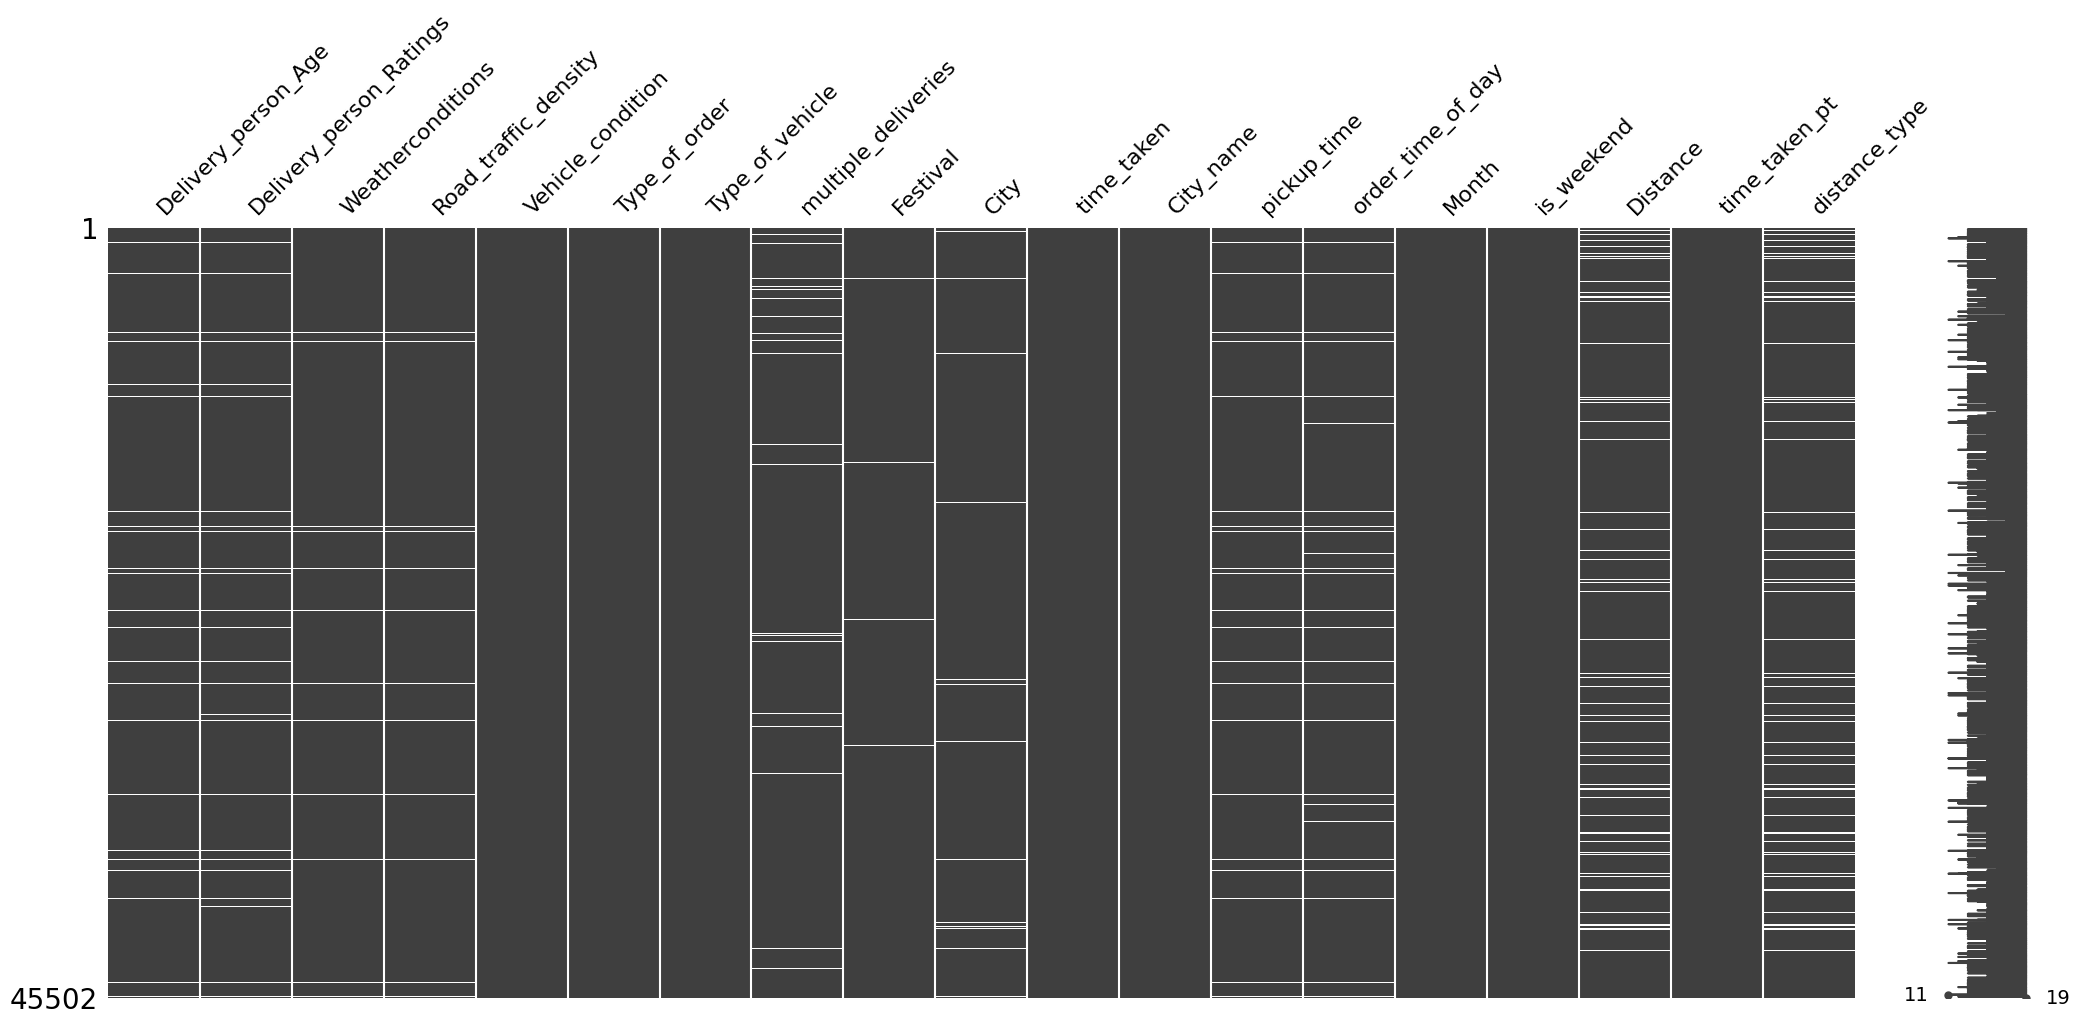

In [221]:
msno.matrix(df)

In [222]:
missing_cols = df.isna().any(axis=0).loc[lambda x:x].index

In [223]:
missing_cols

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Weatherconditions',
       'Road_traffic_density', 'multiple_deliveries', 'Festival', 'City',
       'pickup_time', 'order_time_of_day', 'Distance', 'distance_type'],
      dtype='object')

# Data Prep without missing values by dropping it ( not imputation)

In [224]:
temp_df = df.copy().dropna()

In [225]:
temp_df.drop(columns='time_taken_pt',inplace=True)

In [226]:
temp_df.shape

(37695, 18)

In [419]:
temp_df.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
       'time_taken', 'pickup_time', 'order_time_of_day', 'is_weekend',
       'Distance', 'distance_type'],
      dtype='object')

In [227]:
X = temp_df.drop(columns='time_taken')
y= temp_df['time_taken']

In [228]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [229]:
print('The number of rows in training set is', X_train.shape[0])
print('The number of rows in test set is',X_test.shape[0])

The number of rows in training set is 30156
The number of rows in test set is 7539


In [230]:
df.Vehicle_condition=df.Vehicle_condition.astype('object')
df.Month = df.Month.astype('object')

In [231]:
temp_df.multiple_deliveries=temp_df.multiple_deliveries.astype(int)

In [420]:
temp_df.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
       'time_taken', 'pickup_time', 'order_time_of_day', 'is_weekend',
       'Distance', 'distance_type'],
      dtype='object')

In [232]:
num_cols =['Delivery_person_Age', 'Delivery_person_Ratings','pickup_time','Distance']
nominal_cat_cols = ['Weatherconditions', 'Type_of_order',
       'Type_of_vehicle', 'Festival', 'City', 'City_name', 'order_time_of_day', 'Month',
       'is_weekend']
ordinal_cat_cols = ['distance_type','Road_traffic_density']

In [233]:
len(num_cols+nominal_cat_cols+ordinal_cat_cols)

15

In [234]:
# define order for ordinal variables
distance_type_order = ['short','medium','long','very long']
road_traffic_order = ['low','medium','high','jam']

In [235]:
# build a preprocessor
preprocessor = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories=[distance_type_order,road_traffic_order]), ordinal_cat_cols)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

preprocessor.set_output(transform="pandas")

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['Delivery_person_Age',
                                  'Delivery_person_Ratings', 'pickup_time',
                                  'Distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Weatherconditions', 'Type_of_order',
                                  'Type_of_vehicle', 'Festival', 'City',
                                  'City_name', 'order_time_of_day', 'Month',
                                  'is_weekend']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['short', 'medium',
                                                             'long',
                                                             'very long'],
                                                            ['low', 'medium',
                                                             'high', 'jam']]),
                                 ['distance_type', 'Road_traffic_density'])],
                  verbose_feature_names_out=False)

In [236]:
# transform the data

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

In [237]:
X_train_trans.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'pickup_time',
       'Distance', 'Weatherconditions_Fog', 'Weatherconditions_Sandstorms',
       'Weatherconditions_Stormy', 'Weatherconditions_Sunny',
       'Weatherconditions_Windy', 'Type_of_order_drinks', 'Type_of_order_meal',
       'Type_of_order_snack', 'Type_of_vehicle_motorcycle',
       'Type_of_vehicle_scooter', 'Festival_Yes ', 'City_semi-urban',
       'City_urban', 'City_name_Allahabad', 'City_name_Aurangabad',
       'City_name_Bangalore', 'City_name_Bhopal', 'City_name_Chennai',
       'City_name_Coimbatore', 'City_name_Delhi', 'City_name_Goa',
       'City_name_Hyderabad', 'City_name_Indore', 'City_name_Jaipur',
       'City_name_Kanpur', 'City_name_Kochi', 'City_name_Kolkata',
       'City_name_Ludhiana', 'City_name_Mumbai', 'City_name_Mysore',
       'City_name_Pune', 'City_name_Ranchi', 'City_name_Surat',
       'City_name_Vadodara', 'order_time_of_day_Evening',
       'order_time_of_day_Morning', 'order_tim

In [238]:
pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [239]:
y_train_pt

array([[ 2.02867161],
       [ 0.55453913],
       [-2.02426721],
       ...,
       [-1.35093653],
       [ 0.04711066],
       [ 0.2571302 ]])

In [240]:
temp_df.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
       'time_taken', 'City_name', 'pickup_time', 'order_time_of_day', 'Month',
       'is_weekend', 'Distance', 'distance_type'],
      dtype='object')

# Train Initial Baseline Model

In [241]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_trans,y_train_pt)

LinearRegression()

In [242]:
# get the predictions
y_pred_train = lr.predict(X_train_trans)
y_pred_test = lr.predict(X_test_trans)

In [243]:
# get the actual predictions values

y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [244]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f"The train error is {mean_absolute_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_test,y_pred_test_org):.2f} minutes")

The train error is 4.69 minutes
The test error is 4.68 minutes


In [245]:
print(f"The train r2 score is {r2_score(y_train,y_pred_train_org):.2f}")
print(f"The test r2 score is {r2_score(y_test,y_pred_test_org):.2f}")

The train r2 score is 0.60
The test r2 score is 0.60


# Imputing missing values 

In [246]:
temp_df2 = df.copy()

In [247]:
temp_df2.drop(columns='time_taken_pt',inplace=True)

In [ ]:
temp_df.drop(columns=['City_name','Month'],inplace=True)

In [248]:
# split into X and y

X = temp_df2.drop(columns='time_taken')
y = temp_df2['time_taken']

X

,Delivery_person_Age,Delivery_person_Ratings,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,City_name,pickup_time,order_time_of_day,Month,is_weekend,Distance,distance_type
0,37.0,4.9,Sunny,high,2,snack,motorcycle,0,No,urban,Indore,15.0,Morning,3,1,3.028853,short
1,34.0,4.5,Stormy,jam,2,snack,scooter,1,No,metropolitian,Bangalore,5.0,Evening,3,0,20.208240,very long
2,23.0,4.4,Sandstorms,low,0,drinks,motorcycle,1,No,urban,Bangalore,15.0,Morning,3,1,1.554659,short
3,38.0,4.7,Sunny,medium,0,buffet,motorcycle,1,No,metropolitian,Coimbatore,10.0,Evening,4,0,7.799939,medium
4,32.0,4.6,Cloudy,high,1,snack,scooter,1,No,metropolitian,Chennai,15.0,Afternoon,3,1,6.217741,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,30.0,4.8,Windy,high,1,meal,motorcycle,0,No,metropolitian,Jaipur,10.0,Morning,3,0,1.491670,short
45589,21.0,4.6,Windy,jam,0,buffet,motorcycle,1,No,metropolitian,Agra,15.0,Evening,2,0,NaN,NaN
45590,30.0,4.9,Cloudy,low,1,drinks,scooter,0,No,metropolitian,Chennai,15.0,Night,3,0,4.662897,medium
45591,20.0,4.7,Cloudy,high,0,snack,motorcycle,1,No,metropolitian,Coimbatore,5.0,Afternoon,3,0,6.240023,medium


In [249]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [250]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (36401, 17)
The shape of test data is (9101, 17)


In [251]:
# missing values in train data

X_train.isna().sum()

Delivery_person_Age        1470
Delivery_person_Ratings    1510
Weatherconditions           421
Road_traffic_density        407
Vehicle_condition             0
Type_of_order                 0
Type_of_vehicle               0
multiple_deliveries         795
Festival                    188
City                        968
City_name                     0
pickup_time                1298
order_time_of_day          1646
Month                         0
is_weekend                    0
Distance                   2931
distance_type              2931
dtype: int64

In [252]:
# transform target column

pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [253]:
X_train.isna().any(axis=1).mean().round(2)*100

17.0

In [254]:
missing_cols

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Weatherconditions',
       'Road_traffic_density', 'multiple_deliveries', 'Festival', 'City',
       'pickup_time', 'order_time_of_day', 'Distance', 'distance_type'],
      dtype='object')

In [255]:
#Age
X_train.Delivery_person_Age.describe() # avg and median values are similar so impute the age column with median value

count    34931.000000
mean        29.569551
std          5.752869
min         20.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         39.000000
Name: Delivery_person_Age, dtype: float64

In [256]:
age_median = X_train['Delivery_person_Age'].median()

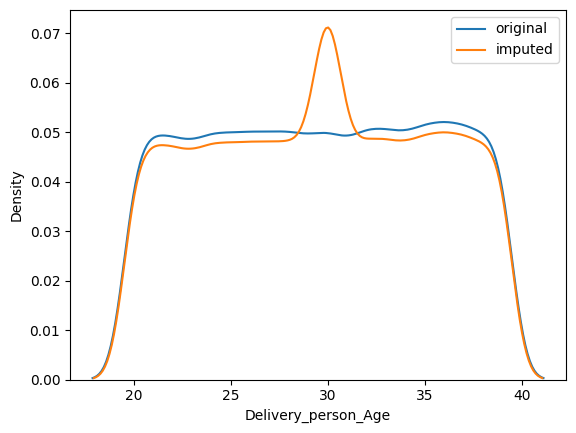

In [257]:
# plot the kde plot

sns.kdeplot(X_train['Delivery_person_Age'],label="original")
sns.kdeplot(X_train['Delivery_person_Age'].fillna(age_median),label="imputed")
plt.legend()
# we see there is a peak at 30 , since lot of missing values r getting imputed by 30 , and hence this imputation technique is not reliable as it distort our original distribution of the date

**Observation**:

1. Changed the distribution of the age column.
2. Use Advanced imputation techniques like KNN imputer.

In [258]:
# ratings
X_train.Delivery_person_Ratings.describe()

count    34891.000000
mean         4.635058
std          0.314049
min          2.500000
25%          4.500000
50%          4.700000
75%          4.900000
max          5.000000
Name: Delivery_person_Ratings, dtype: float64

In [259]:
X_train.Delivery_person_Age.isna().sum()

1470

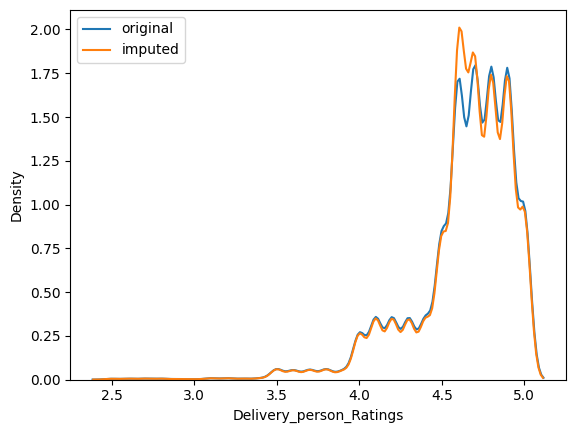

In [260]:
# avg rating

ratings_mean = X_train['Delivery_person_Ratings'].mean()

# fill and plot kdeplot

sns.kdeplot(X_train['Delivery_person_Ratings'],label="original")
sns.kdeplot(X_train['Delivery_person_Ratings'].fillna(ratings_mean),label="imputed")
plt.legend()
# not much differ but still we can use better imputation techniaue

In [261]:
#Weather
X_train.Weatherconditions.value_counts() # since our data is uniform we can use mode value , if not-uniform a mode value will shift out distribution or say it will create a peak and sitort the data

Weatherconditions
Fog           6160
Stormy        6051
Cloudy        6033
Sandstorms    5958
Windy         5928
Sunny         5850
Name: count, dtype: int64

There are 420 arund missing values , so if we take the mode that is Fog it will distort the distn as Fog value will be incrrease to 6160+420 , so there is no dominant categorty to choose from

In [262]:
df.Road_traffic_density.value_counts() # again no dominant category so we perform imputation later

Road_traffic_density
low       15477
jam       14143
medium    10947
high       4425
Name: count, dtype: int64

In [263]:
#multiple_Deliveries 
X_train.multiple_deliveries.value_counts()
# we have a dominant category of 1 so we can use mode to impute the missing values

multiple_deliveries
1    22487
0    11252
2     1599
3      268
Name: count, dtype: int64

In [264]:
X_train.multiple_deliveries.isna().sum()

795

<Axes: xlabel='count', ylabel='multiple_deliveries'>

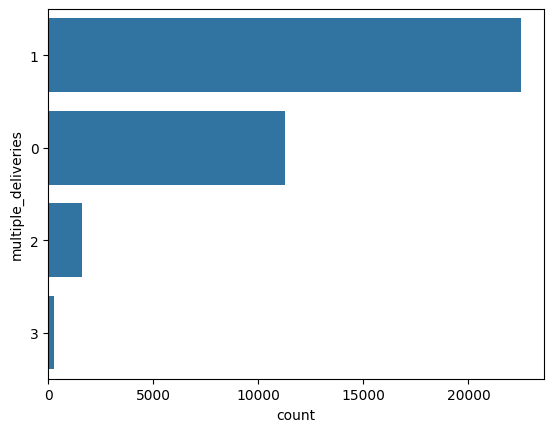

In [265]:
sns.countplot(X_train.multiple_deliveries,label='non-imputed')

<Axes: xlabel='count', ylabel='multiple_deliveries'>

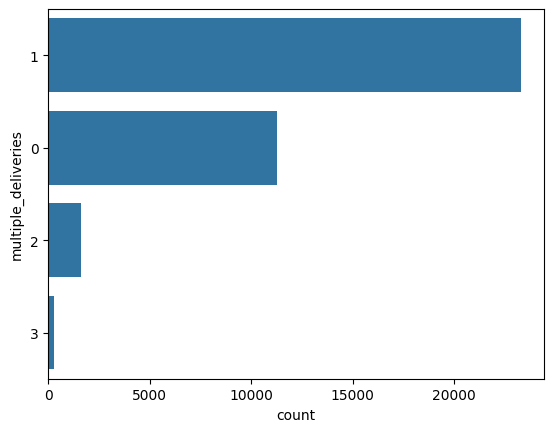

In [266]:

sns.countplot(X_train.multiple_deliveries.fillna(X_train.multiple_deliveries.mode()[0]))


In [267]:
# Festival
X_train.Festival.value_counts() # here also we can impute with mode

Festival
No      35474
Yes       739
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='multiple_deliveries'>

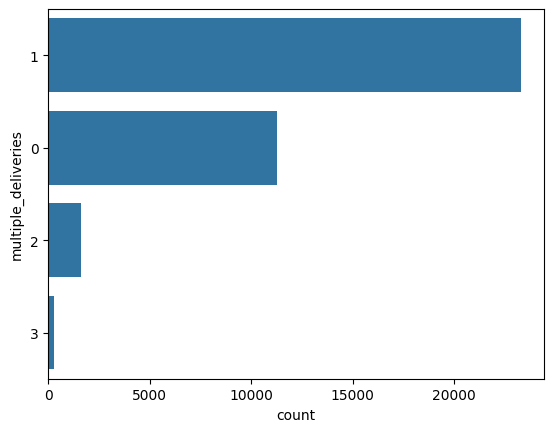

In [268]:
sns.countplot(X_train.multiple_deliveries.fillna(X_train.multiple_deliveries.mode()[0]))

In [269]:
# City
X_train.City.value_counts() # use mode here for imputation

City
metropolitian    27245
urban             8058
semi-urban         130
Name: count, dtype: int64

In [270]:
df.pickup_time.describe()

count    43862.000000
mean         9.989399
std          4.087516
min          5.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         15.000000
Name: pickup_time, dtype: float64

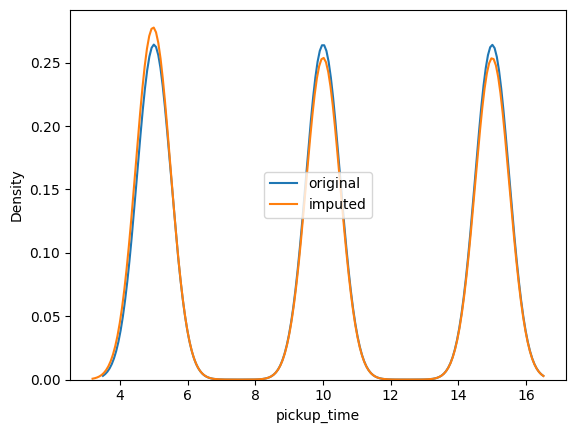

In [271]:
pickup_median = X_train['Delivery_person_Ratings'].median()

# fill and plot kdeplot

sns.kdeplot(X_train['pickup_time'],label="original")
sns.kdeplot(X_train['pickup_time'].fillna(pickup_median),label="imputed")
plt.legend() # use better imputation technique like KNN imputer and iterative imputer

In [272]:
# order_time_of_day
X_train.order_time_of_day.value_counts() # use different imputation techniques
# missing null at random is very hard to impute, the best techniques are to apply GenAI models

order_time_of_day
Night        14620
Evening      10732
Morning       6150
Afternoon     3253
Name: count, dtype: int64

In [273]:
# distance 
X_train.Distance.describe()
# we cant impute with mean as it will make our distn peaked at the mean values as lot of missing values will get same value
# so we use KNN imputer or anyhting else

count    33470.000000
mean         9.750076
std          5.615267
min          1.466861
25%          4.663374
50%          9.204677
75%         13.697807
max         20.995162
Name: Distance, dtype: float64

In [274]:
X_train.distance_type.value_counts() # mode cant be used here

distance_type
medium       11546
long          9025
very long     6454
short         6445
Name: count, dtype: int64

# Imputation Pipeline

In [275]:
nominal_cat_cols

['Weatherconditions',
 'Type_of_order',
 'Type_of_vehicle',
 'Festival',
 'City',
 'City_name',
 'order_time_of_day',
 'Month',
 'is_weekend']

In [276]:
X_train.isna().sum()

Delivery_person_Age        1470
Delivery_person_Ratings    1510
Weatherconditions           421
Road_traffic_density        407
Vehicle_condition             0
Type_of_order                 0
Type_of_vehicle               0
multiple_deliveries         795
Festival                    188
City                        968
City_name                     0
pickup_time                1298
order_time_of_day          1646
Month                         0
is_weekend                    0
Distance                   2931
distance_type              2931
dtype: int64

In [277]:
# features to fill values with mode

features_to_fill_mode = ['multiple_deliveries','Festival','City']
features_to_fill_missing = [col for col in nominal_cat_cols if col not in features_to_fill_mode]

features_to_fill_missing


['Weatherconditions',
 'Type_of_order',
 'Type_of_vehicle',
 'City_name',
 'order_time_of_day',
 'Month',
 'is_weekend']

In [278]:
simple_imputer = ColumnTransformer(transformers=[
    ("mode_imputer",SimpleImputer(strategy="most_frequent"),features_to_fill_mode),
     ("missing_imputer",SimpleImputer(strategy="constant",fill_value="missing"),features_to_fill_missing)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

simple_imputer.set_output(transform="pandas")
simple_imputer

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('mode_imputer',
                                 SimpleImputer(strategy='most_frequent'),
                                 ['multiple_deliveries', 'Festival', 'City']),
                                ('missing_imputer',
                                 SimpleImputer(fill_value='missing',
                                               strategy='constant'),
                                 ['Weatherconditions', 'Type_of_order',
                                  'Type_of_vehicle', 'City_name',
                                  'order_time_of_day', 'Month',
                                  'is_weekend'])],
                  verbose_feature_names_out=False)

In [279]:
X_train = simple_imputer.fit_transform(X_train)

In [280]:
# knn imputer

knn_imputer = KNNImputer(n_neighbors=5)

In [281]:
# do basic preprocessing
num_cols =['Delivery_person_Age', 'Delivery_person_Ratings','pickup_time','Distance']

nominal_cat_cols = ['Weatherconditions', 'Type_of_order',
       'Type_of_vehicle', 'Festival', 'City', 'City_name', 'order_time_of_day', 'Month',
       'is_weekend']
ordinal_cat_cols = ['distance_type','Road_traffic_density']

In [282]:
# generate order for ordinal encoding

traffic_order = ["low","medium","high","jam"]

distance_type_order = ["short","medium","long","very_long"]

In [283]:
X_train.isna().sum()

multiple_deliveries           0
Festival                      0
City                          0
Weatherconditions             0
Type_of_order                 0
Type_of_vehicle               0
City_name                     0
order_time_of_day             0
Month                         0
is_weekend                    0
Delivery_person_Age        1470
Delivery_person_Ratings    1510
Road_traffic_density        407
Vehicle_condition             0
pickup_time                1298
Distance                   2931
distance_type              2931
dtype: int64

In [284]:
# build a preprocessor

preprocessor = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop="first",handle_unknown="ignore",
                                     sparse_output=False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories=[traffic_order,distance_type_order],
                                      encoded_missing_value=-999,
                                      handle_unknown="use_encoded_value",
                                      unknown_value=-1), ordinal_cat_cols)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

preprocessor.set_output(transform="pandas")
preprocessor

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['Delivery_person_Age',
                                  'Delivery_person_Ratings', 'pickup_time',
                                  'Distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Weatherconditions', 'Type_of_order',
                                  'Type_of_vehicle', 'Festival', 'City',
                                  'City_name', 'order_time_of_day', 'Month',
                                  'is_weekend']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['short', 'medium',
                                                             'long',
                                                             'very_long']],
                                                encoded_missing_value=-999,
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['distance_type', 'Road_traffic_density'])],
                  verbose_feature_names_out=False)

In [285]:
preprocessor.fit_transform(X_train)

,Delivery_person_Age,Delivery_person_Ratings,pickup_time,Distance,Weatherconditions_Fog,Weatherconditions_Sandstorms,Weatherconditions_Stormy,Weatherconditions_Sunny,Weatherconditions_Windy,Weatherconditions_missing,...,order_time_of_day_Morning,order_time_of_day_Night,order_time_of_day_missing,Month_3,Month_4,is_weekend_1,distance_type,Road_traffic_density,multiple_deliveries,Vehicle_condition
11047,0.315789,0.88,0.5,0.395429,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,-1.0,1,2
15692,0.052632,0.96,0.0,0.236688,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1,2
14499,NaN,NaN,NaN,0.004588,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,-1.0,-1.0,1,2
29258,0.631579,0.88,1.0,0.993990,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,-1.0,1.0,1,0
22554,0.736842,0.96,0.0,0.389195,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,-1.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11303,0.473684,0.88,0.0,0.563939,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,-1.0,-1.0,0,2
44821,0.842105,0.92,0.5,0.002839,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,-1.0,-1.0,0,0
38234,0.842105,0.76,0.5,NaN,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0,1
860,0.263158,0.96,0.0,0.322792,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1,2


In [286]:
preprocessor.fit_transform(X_train).isna().sum()

Delivery_person_Age                 1470
Delivery_person_Ratings             1510
pickup_time                         1298
Distance                            2931
Weatherconditions_Fog                  0
Weatherconditions_Sandstorms           0
Weatherconditions_Stormy               0
Weatherconditions_Sunny                0
Weatherconditions_Windy                0
Weatherconditions_missing              0
Type_of_order_drinks                   0
Type_of_order_meal                     0
Type_of_order_snack                    0
Type_of_vehicle_electric_scooter       0
Type_of_vehicle_motorcycle             0
Type_of_vehicle_scooter                0
Festival_Yes                           0
City_semi-urban                        0
City_urban                             0
City_name_Allahabad                    0
City_name_Aurangabad                   0
City_name_Bangalore                    0
City_name_Bhopal                       0
City_name_Chennai                      0
City_name_Coimba

In [287]:
processing_pipeline = Pipeline(steps=[
                                ("simple_imputer",simple_imputer),
                                ("preprocess",preprocessor),
                                ("knn_imputer",knn_imputer)
                            ])

processing_pipeline.set_output(transform="pandas")
processing_pipeline

Pipeline(steps=[('simple_imputer',
                 ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                                   remainder='passthrough',
                                   transformers=[('mode_imputer',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['multiple_deliveries',
                                                   'Festival', 'City']),
                                                 ('missing_imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant'),
                                                  ['Weatherconditions',
                                                   'Type_of_order',
                                                   'Type_of...
                                                   'City_name',
                                                   'order_time_of_day', 'Month',
                                                   'is_weekend']),
                                                 ('ordinal_encode',
                                                  OrdinalEncoder(categories=[['low',
                                                                              'medium',
                                                                              'high',
                                                                              'jam'],
                                                                             ['short',
                                                                              'medium',
                                                                              'long',
                                                                              'very_long']],
                                                                 encoded_missing_value=-999,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['distance_type',
                                                   'Road_traffic_density'])],
                                   verbose_feature_names_out=False)),
                ('knn_imputer', KNNImputer())])

In [288]:
processing_pipeline.fit_transform(X_train)

,Delivery_person_Age,Delivery_person_Ratings,pickup_time,Distance,Weatherconditions_Fog,Weatherconditions_Sandstorms,Weatherconditions_Stormy,Weatherconditions_Sunny,Weatherconditions_Windy,Weatherconditions_missing,...,order_time_of_day_Morning,order_time_of_day_Night,order_time_of_day_missing,Month_3,Month_4,is_weekend_1,distance_type,Road_traffic_density,multiple_deliveries,Vehicle_condition
11047,0.315789,0.880,0.5,0.395429,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,-1.0,1.0,2.0
15692,0.052632,0.960,0.0,0.236688,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,2.0
14499,0.421053,0.808,0.6,0.004588,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,-1.0,-1.0,1.0,2.0
29258,0.631579,0.880,1.0,0.993990,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,-1.0,1.0,1.0,0.0
22554,0.736842,0.960,0.0,0.389195,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,-1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11303,0.473684,0.880,0.0,0.563939,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,-1.0,-1.0,0.0,2.0
44821,0.842105,0.920,0.5,0.002839,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,-1.0,-1.0,0.0,0.0
38234,0.842105,0.760,0.5,0.660209,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,1.0
860,0.263158,0.960,0.0,0.322792,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,2.0


In [289]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

model_pipe = Pipeline(steps=[
                                ("preprocessing",processing_pipeline),
                                ("model",lr)
                            ])

model_pipe

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['multiple_deliveries',
                                                                    'Festival',
                                                                    'City']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),
                                                                   ['Weathercon...
                                                                    'Month',
                                                                    'is_weekend']),
                                                                  ('ordinal_encode',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high',
                                                                                               'jam'],
                                                                                              ['short',
                                                                                               'medium',
                                                                                               'long',
                                                                                               'very_long']],
                                                                                  encoded_missing_value=-999,
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1),
                                                                   ['distance_type',
                                                                    'Road_traffic_density'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model', LinearRegression())])

In [290]:
model_pipe.fit(X_train,y_train_pt)

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['multiple_deliveries',
                                                                    'Festival',
                                                                    'City']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),
                                                                   ['Weathercon...
                                                                    'Month',
                                                                    'is_weekend']),
                                                                  ('ordinal_encode',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high',
                                                                                               'jam'],
                                                                                              ['short',
                                                                                               'medium',
                                                                                               'long',
                                                                                               'very_long']],
                                                                                  encoded_missing_value=-999,
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1),
                                                                   ['distance_type',
                                                                    'Road_traffic_density'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model', LinearRegression())])

In [291]:
y_pred_train = model_pipe.predict(X_train)
y_pred_test = model_pipe.predict(X_test)

In [292]:
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [293]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f"The train error is {mean_absolute_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_test,y_pred_test_org):.2f} minutes")

The train error is 5.19 minutes
The test error is 5.29 minutes


In [294]:
print(f"The train r2 score is {r2_score(y_train,y_pred_train_org):.2f}")
print(f"The test r2 score is {r2_score(y_test,y_pred_test_org):.2f}")

The train r2 score is 0.52
The test r2 score is 0.50


In [295]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42,n_jobs=-1)

model_pipe = Pipeline(steps=[
                                ("preprocessing",processing_pipeline),
                                ("model",rf)
                            ])

model_pipe

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['multiple_deliveries',
                                                                    'Festival',
                                                                    'City']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),
                                                                   ['Weathercon...
                                                                  ('ordinal_encode',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high',
                                                                                               'jam'],
                                                                                              ['short',
                                                                                               'medium',
                                                                                               'long',
                                                                                               'very_long']],
                                                                                  encoded_missing_value=-999,
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1),
                                                                   ['distance_type',
                                                                    'Road_traffic_density'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

In [296]:
model_pipe.fit(X_train,y_train_pt)

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['multiple_deliveries',
                                                                    'Festival',
                                                                    'City']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),
                                                                   ['Weathercon...
                                                                  ('ordinal_encode',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high',
                                                                                               'jam'],
                                                                                              ['short',
                                                                                               'medium',
                                                                                               'long',
                                                                                               'very_long']],
                                                                                  encoded_missing_value=-999,
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1),
                                                                   ['distance_type',
                                                                    'Road_traffic_density'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

In [297]:
y_pred_train = model_pipe.predict(X_train)
y_pred_test = model_pipe.predict(X_test)

In [292]:
# get the actual predictions values

y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [293]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f"The train error is {mean_absolute_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_test,y_pred_test_org):.2f} minutes")

The train error is 5.19 minutes
The test error is 5.29 minutes


In [294]:
print(f"The train r2 score is {r2_score(y_train,y_pred_train_org):.2f}")
print(f"The test r2 score is {r2_score(y_test,y_pred_test_org):.2f}")

The train r2 score is 0.52
The test r2 score is 0.50


In [301]:
# By dropping missing value lets check the rf r2 score , and lets whether imputation gives us any advantage or not

In [295]:
temp_df.drop(columns=['City_name','Month'],inplace=True)

In [296]:
Xd = temp_df.drop(columns='time_taken')
yd= temp_df['time_taken']

In [297]:
X_traind, X_testd, y_traind, y_testd = train_test_split(Xd, yd, test_size=0.2, random_state=42)

In [421]:
temp_df.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
       'time_taken', 'pickup_time', 'order_time_of_day', 'is_weekend',
       'Distance', 'distance_type'],
      dtype='object')

In [298]:
num_cols =['Delivery_person_Age', 'Delivery_person_Ratings','pickup_time','Distance']
nominal_cat_cols = ['Weatherconditions', 'Type_of_order',
       'Type_of_vehicle', 'Festival', 'City',  'order_time_of_day', 
       'is_weekend']
ordinal_cat_cols = ['distance_type','Road_traffic_density']

In [299]:
# define order for ordinal variables
distance_type_order = ['short','medium','long','very long']
road_traffic_order = ['low','medium','high','jam']

In [300]:
# build a preprocessor
preprocessor_not_impute = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories=[distance_type_order,road_traffic_order,]), ordinal_cat_cols)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

preprocessor_not_impute.set_output(transform="pandas")

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['Delivery_person_Age',
                                  'Delivery_person_Ratings', 'pickup_time',
                                  'Distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Weatherconditions', 'Type_of_order',
                                  'Type_of_vehicle', 'Festival', 'City',
                                  'order_time_of_day', 'is_weekend']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['short', 'medium',
                                                             'long',
                                                             'very long'],
                                                            ['low', 'medium',
                                                             'high', 'jam']]),
                                 ['distance_type', 'Road_traffic_density'])],
                  verbose_feature_names_out=False)

In [301]:
# transform the data

X_train_transd = preprocessor_not_impute.fit_transform(X_traind)
X_test_transd = preprocessor_not_impute.transform(X_testd)

In [360]:
len(X_train_transd.columns)

25

In [302]:
# transform target column

pt = PowerTransformer()

y_train_ptd = pt.fit_transform(y_traind.values.reshape(-1,1))
y_test_ptd = pt.transform(y_testd.values.reshape(-1,1))

In [303]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(X_train_transd,y_train_ptd)

RandomForestRegressor()

In [304]:
# get the predictions
y_pred_traind = rf.predict(X_train_transd)
y_pred_testd = rf.predict(X_test_transd)

In [305]:
# get the actual predictions values

y_pred_train_orgd = pt.inverse_transform(y_pred_traind.reshape(-1,1))
y_pred_test_orgd = pt.inverse_transform(y_pred_testd.reshape(-1,1))

In [306]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f"The train error is {mean_absolute_error(y_traind,y_pred_train_orgd):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_testd,y_pred_test_orgd):.2f} minutes")

The train error is 1.15 minutes
The test error is 3.08 minutes


In [307]:
print(f"The train r2 score is {r2_score(y_traind,y_pred_train_orgd):.2f}")
print(f"The test r2 score is {r2_score(y_testd,y_pred_test_orgd):.2f}")

The train r2 score is 0.98
The test r2 score is 0.83


In [315]:
# we see by imputing missing values our r2 score decrease and hence we drop the missing values and move on . Everything is a experimentation so we needed to see what happens by applying imputations

In [308]:
# now we apply various models on our dropped missing value dataframe(Temp_df) and use optuna to get our best model

# Before applying various models , lets try feature selection and select the best features

In [310]:
# 1- Variance threshold :- We wont be using it here as it dont consider the features importance with the target columns and in our data may features impact our target directly

<Axes: >

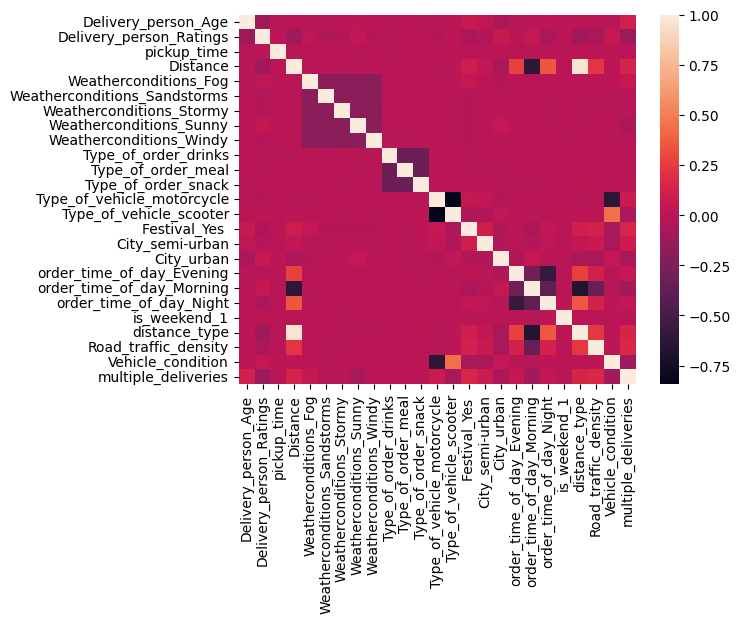

In [312]:
sns.heatmap(X_train_transd.corr())

In [313]:
corr_matrix = X_train_transd.corr()

In [322]:
columns = corr_matrix.columns

cols_to_drop = []
for i in range(1,len(columns)):
    for j in range(i+1,len(columns)):
        if corr_matrix.loc[columns[i],columns[j]]>0.95:
                cols_to_drop.append(columns[j])

In [326]:
cols_to_drop = set(cols_to_drop)

In [327]:
cols_to_drop

{'distance_type'}

In [329]:
# Import library for VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(X):

    # Calculating VIF
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return(vif)

In [330]:
calc_vif(X_train_transd)

,variables,VIF
0,Delivery_person_Age,3.703268
1,Delivery_person_Ratings,23.074218
2,pickup_time,2.458880
3,Distance,47.343545
4,Weatherconditions_Fog,1.967182
5,Weatherconditions_Sandstorms,1.923187
6,Weatherconditions_Stormy,1.946934
7,Weatherconditions_Sunny,1.931833
8,Weatherconditions_Windy,1.936435
9,Type_of_order_drinks,1.964085


In [350]:
X_train_transd_vif = X_train_transd.drop(columns=['distance_type','Delivery_person_Ratings','Type_of_vehicle_motorcycle'])
X_test_transd_vif = X_test_transd.drop(columns=['distance_type','Delivery_person_Ratings','Type_of_vehicle_motorcycle'])

In [351]:
X_train_transd_vif.columns

Index(['Delivery_person_Age', 'pickup_time', 'Distance',
       'Weatherconditions_Fog', 'Weatherconditions_Sandstorms',
       'Weatherconditions_Stormy', 'Weatherconditions_Sunny',
       'Weatherconditions_Windy', 'Type_of_order_drinks', 'Type_of_order_meal',
       'Type_of_order_snack', 'Type_of_vehicle_scooter', 'Festival_Yes ',
       'City_semi-urban', 'City_urban', 'order_time_of_day_Evening',
       'order_time_of_day_Morning', 'order_time_of_day_Night', 'is_weekend_1',
       'Road_traffic_density', 'Vehicle_condition', 'multiple_deliveries'],
      dtype='object')

In [359]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train_transd_vif,y_train_ptd)

RandomForestRegressor()

In [353]:
y_pred_traind_vif = rf.predict(X_train_transd_vif)
y_pred_testd_vif = rf.predict(X_test_transd_vif)

In [354]:
# get the actual predictions values

y_pred_train_orgd_vif = pt.inverse_transform(y_pred_traind_vif.reshape(-1,1))
y_pred_test_orgd_vif = pt.inverse_transform(y_pred_testd_vif.reshape(-1,1))

In [355]:
print(f"The train error is {mean_absolute_error(y_traind,y_pred_train_orgd_vif):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_testd,y_pred_test_orgd_vif):.2f} minutes")

The train error is 1.26 minutes
The test error is 3.36 minutes


In [356]:
print(f"The train r2 score is {r2_score(y_traind,y_pred_train_orgd_vif):.2f}")
print(f"The test r2 score is {r2_score(y_testd,y_pred_test_orgd_vif):.2f}")

The train r2 score is 0.97
The test r2 score is 0.80


In [ ]:
# By using vif feature selection , we are not getting a better score , lets try other feature selection methods

In [368]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
sfs = SFS(rf,k_features='best',forward=False,floating=False,scoring='r2',n_jobs=-1,cv=5)
sfs.fit(X_train_transd,y_train_ptd)

SequentialFeatureSelector(estimator=RandomForestRegressor(), forward=False,
                          k_features=(1, 25), n_jobs=-1, scoring='r2')

In [377]:
list(sfs.k_feature_idx_)

[0, 1, 2, 3, 5, 6, 7, 8, 9, 11, 13, 14, 15, 17, 20, 22, 23, 24]

In [373]:
metric_df = pd.DataFrame.from_dict(sfs.get_metric_dict()).T
metric_df

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
25,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.8084707437053212, 0.8098878158940458, 0.812...",0.810531,"(Delivery_person_Age, Delivery_person_Ratings,...",0.001939,0.001509,0.000754
24,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.8078678134090435, 0.8131903048050899, 0.815...",0.811919,"(Delivery_person_Age, Delivery_person_Ratings,...",0.003344,0.002602,0.001301
23,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.8071591853143525, 0.8126450982643906, 0.816...",0.81193,"(Delivery_person_Age, Delivery_person_Ratings,...",0.003937,0.003063,0.001532
22,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.8061193458981742, 0.8123377584339271, 0.815...",0.81145,"(Delivery_person_Age, Delivery_person_Ratings,...",0.00423,0.003291,0.001646
21,"(0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[0.8072723223223035, 0.8131354141108653, 0.815...",0.811671,"(Delivery_person_Age, Delivery_person_Ratings,...",0.003546,0.002759,0.00138
20,"(0, 1, 2, 3, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15...","[0.8062019395042637, 0.813062040847705, 0.8159...",0.811725,"(Delivery_person_Age, Delivery_person_Ratings,...",0.004101,0.003191,0.001596
19,"(0, 1, 2, 3, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15...","[0.8056347975320958, 0.8133667299501214, 0.815...",0.811619,"(Delivery_person_Age, Delivery_person_Ratings,...",0.004228,0.003289,0.001645
18,"(0, 1, 2, 3, 5, 6, 7, 8, 9, 11, 13, 14, 15, 17...","[0.8065653434997905, 0.8140539301491849, 0.815...",0.811932,"(Delivery_person_Age, Delivery_person_Ratings,...",0.004016,0.003125,0.001562
17,"(0, 1, 2, 3, 5, 6, 7, 8, 9, 11, 13, 14, 15, 17...","[0.8054087715033583, 0.8126773189549309, 0.814...",0.811169,"(Delivery_person_Age, Delivery_person_Ratings,...",0.004193,0.003262,0.001631
16,"(0, 1, 2, 3, 5, 6, 7, 8, 9, 13, 14, 15, 17, 22...","[0.8045956757061774, 0.8114737054228764, 0.814...",0.810616,"(Delivery_person_Age, Delivery_person_Ratings,...",0.004588,0.003569,0.001785


In [382]:
X_train_transd_sfs = X_train_transd.iloc[:,list(sfs.k_feature_idx_)]
X_test_transd_sfs = X_test_transd.iloc[:,list(sfs.k_feature_idx_)]

In [ ]:
rf.fit()

In [381]:
X_train_transd.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'pickup_time',
       'Distance', 'Weatherconditions_Fog', 'Weatherconditions_Sandstorms',
       'Weatherconditions_Stormy', 'Weatherconditions_Sunny',
       'Weatherconditions_Windy', 'Type_of_order_drinks', 'Type_of_order_meal',
       'Type_of_order_snack', 'Type_of_vehicle_motorcycle',
       'Type_of_vehicle_scooter', 'Festival_Yes ', 'City_semi-urban',
       'City_urban', 'order_time_of_day_Evening', 'order_time_of_day_Morning',
       'order_time_of_day_Night', 'is_weekend_1', 'distance_type',
       'Road_traffic_density', 'Vehicle_condition', 'multiple_deliveries'],
      dtype='object')

In [385]:
rf = RandomForestRegressor()

rf.fit(X_train_transd_sfs,y_train_ptd)

RandomForestRegressor()

In [386]:
# get the predictions
y_pred_traind_sfs = rf.predict(X_train_transd_sfs)
y_pred_testd_sfs = rf.predict(X_test_transd_sfs)

In [387]:
y_pred_train_orgd_sfs = pt.inverse_transform(y_pred_traind_sfs.reshape(-1,1))
y_pred_test_orgd_sfs = pt.inverse_transform(y_pred_testd_sfs.reshape(-1,1))

In [388]:
print(f"The train error is {mean_absolute_error(y_traind,y_pred_train_orgd_sfs):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_testd,y_pred_test_orgd_sfs):.2f} minutes")

The train error is 1.15 minutes
The test error is 3.10 minutes


In [389]:
print(f"The train r2 score is {r2_score(y_traind,y_pred_train_orgd_sfs):.2f}")
print(f"The test r2 score is {r2_score(y_testd,y_pred_test_orgd_sfs):.2f}")

The train r2 score is 0.98
The test r2 score is 0.83


In [390]:
# almost same output still by sfs we have a bit higher test error , so we still going with all features

In [391]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train_transd,y_train_ptd)

RandomForestRegressor()

In [394]:
rf.feature_importances_

array([0.11933525, 0.21186932, 0.01151165, 0.13397444, 0.03281696,
       0.02307093, 0.01934523, 0.07810387, 0.01858808, 0.00553696,
       0.00554192, 0.00538399, 0.00315873, 0.00342493, 0.00635294,
       0.00082993, 0.00734276, 0.00230676, 0.00066781, 0.00205472,
       0.00585065, 0.0172164 , 0.15163844, 0.080559  , 0.05351835])

In [397]:
from sklearn.feature_selection import RFE
rfe = RFE(estimator = rf , n_features_to_select=20)

rfe.fit(X_train_transd,y_traind)
ranking = rfe.ranking_
print('Feature ranking:')
for i,feature in enumerate(X_train_transd.columns):
    print(f"{feature}:{ranking[i]}")

Feature ranking:
Delivery_person_Age:1
Delivery_person_Ratings:1
pickup_time:1
Distance:1
Weatherconditions_Fog:1
Weatherconditions_Sandstorms:1
Weatherconditions_Stormy:1
Weatherconditions_Sunny:1
Weatherconditions_Windy:1
Type_of_order_drinks:1
Type_of_order_meal:1
Type_of_order_snack:1
Type_of_vehicle_motorcycle:3
Type_of_vehicle_scooter:1
Festival_Yes :1
City_semi-urban:5
City_urban:1
order_time_of_day_Evening:2
order_time_of_day_Morning:6
order_time_of_day_Night:4
is_weekend_1:1
distance_type:1
Road_traffic_density:1
Vehicle_condition:1
multiple_deliveries:1


In [409]:
features = ['Delivery_person_Age',
'Delivery_person_Ratings',
'pickup_time',
'Distance',
'Weatherconditions_Fog',
'Weatherconditions_Sandstorms',
'Weatherconditions_Stormy',
'Weatherconditions_Sunny',
'Weatherconditions_Windy',
'Type_of_order_drinks',
'Type_of_order_meal',
'Type_of_order_snack',
'Type_of_vehicle_scooter',
'Festival_Yes ',
'City_urban',
'is_weekend_1',
'distance_type',
'Road_traffic_density',
'Vehicle_condition',
'multiple_deliveries']

In [412]:
X_train_transd_rfe = X_train_transd[features]
X_test_transd_rfe = X_test_transd[features]

In [414]:
rf.fit(X_train_transd_rfe,y_train_ptd)

RandomForestRegressor()

In [415]:
y_pred_traind_rfe = rf.predict(X_train_transd_rfe)
y_pred_testd_rfe = rf.predict(X_test_transd_rfe)

In [416]:
y_pred_train_orgd_rfe = pt.inverse_transform(y_pred_traind_rfe.reshape(-1,1))
y_pred_test_orgd_rfe = pt.inverse_transform(y_pred_testd_rfe.reshape(-1,1))

In [417]:
print(f"The train error is {mean_absolute_error(y_traind,y_pred_train_orgd_rfe):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_testd,y_pred_test_orgd_rfe):.2f} minutes")

The train error is 1.16 minutes
The test error is 3.10 minutes


In [418]:
print(f"The train r2 score is {r2_score(y_traind,y_pred_train_orgd_rfe):.2f}")
print(f"The test r2 score is {r2_score(y_testd,y_pred_test_orgd_rfe):.2f}")

The train r2 score is 0.98
The test r2 score is 0.82


In [ ]:
# even after rfe , out initial model considering all colums performs better so we move with it

In [331]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna

In [328]:
def objective(trial):
        model_name = trial.suggest_categorical("model",["SVM","RF","KNN","GB","XGB","LGBM"])

        if model_name == "SVM":
            kernel_svm = trial.suggest_categorical("kernel_svm",["linear","poly","rbf"])
            if kernel_svm == "linear":
                c_linear = trial.suggest_float("c_linear",0,5)
                model = SVR(C=c_linear,kernel="linear")

            elif kernel_svm == "poly":
                c_poly = trial.suggest_float("c_poly",0,10)
                degree_poly = trial.suggest_int("degree_poly",1,3)
                model = SVR(C=c_poly,degree=degree_poly,
                            kernel="poly")

            else:
                c_rbf = trial.suggest_float("c_rbf",0,100)
                gamma_rbf = trial.suggest_float("gamma_rbf",0,3)
                model = SVR(C=c_rbf,gamma=gamma_rbf,
                            kernel="rbf")

        elif model_name == "RF":
            n_estimators_rf = trial.suggest_int("n_estimators_rf",10,100)
            max_depth_rf = trial.suggest_int("max_depth_rf",2,10)
            model = RandomForestRegressor(n_estimators=n_estimators_rf,
                                        max_depth=max_depth_rf,
                                        random_state=42,
                                        n_jobs=-1)

        elif model_name == "GB":
            n_estimators_gb = trial.suggest_int("n_estimators_gb",10,100)
            learning_rate_gb = trial.suggest_float("learning_rate_gb",0,1)
            max_depth_gb = trial.suggest_int("max_depth_gb",2,20)
            model = GradientBoostingRegressor(n_estimators=n_estimators_gb,
                                                learning_rate=learning_rate_gb,
                                                max_depth=max_depth_gb,
                                                random_state=42)

        elif model_name == "KNN":
            n_neighbors_knn = trial.suggest_int("n_neighbors_knn",1,20)
            weights_knn = trial.suggest_categorical("weights_knn",["uniform","distance"])
            model = KNeighborsRegressor(n_neighbors=n_neighbors_knn,
                                        weights=weights_knn,n_jobs=-1)

        elif model_name == "XGB":
            n_estimators_xgb = trial.suggest_int("n_estimators_xgb",10,150)
            learning_rate_xgb = trial.suggest_float("learning_rate_xgb",0.1,0.5)
            max_depth_xgb = trial.suggest_int("max_depth_xgb",2,15)
            model = XGBRegressor(n_estimators=n_estimators_xgb,
                                    learning_rate=learning_rate_xgb,
                                    max_depth=max_depth_xgb,
                                    random_state=42,
                                    n_jobs=-1)

        elif model_name == "LGBM":
            n_estimators_lgbm = trial.suggest_int("n_estimators_lgbm",10,200)
            learning_rate_lgbm = trial.suggest_float("learning_rate_lgbm",0.1,0.5)
            max_depth_lgbm = trial.suggest_int("max_depth_lgbm",2,20)
            model = LGBMRegressor(n_estimators=n_estimators_lgbm,
                                    learning_rate=learning_rate_lgbm,
                                    max_depth=max_depth_lgbm,
                                    random_state=42,n_jobs=-1)


        # train the model
        model.fit(X_train_transd,y_train_ptd)


        # get the predictions
        y_pred_traind = model.predict(X_train_transd)
        y_pred_testd = model.predict(X_test_transd)

        # get the actual predictions values
        y_pred_train_org = pt.inverse_transform(y_pred_traind.reshape(-1,1))
        y_pred_test_org = pt.inverse_transform(y_pred_testd.reshape(-1,1))

        # calculate the error
        error = mean_absolute_error(y_testd,y_pred_test_org)

        return error

In [329]:
# create optuna study
study = optuna.create_study(direction="minimize",study_name="model_selection")

# optimize the objective function
study.optimize(objective,n_trials=30,n_jobs=-1)


[I 2025-04-22 07:06:13,491] A new study created in memory with name: model_selection
[I 2025-04-22 07:06:16,748] Trial 4 finished with value: 5.212389891213645 and parameters: {'model': 'RF', 'n_estimators_rf': 30, 'max_depth_rf': 3}. Best is trial 4 with value: 5.212389891213645.
[I 2025-04-22 07:06:16,869] Trial 2 finished with value: 4.2897739211200685 and parameters: {'model': 'RF', 'n_estimators_rf': 61, 'max_depth_rf': 5}. Best is trial 2 with value: 4.2897739211200685.
[I 2025-04-22 07:06:17,156] Trial 0 finished with value: 3.5305145704829064 and parameters: {'model': 'RF', 'n_estimators_rf': 78, 'max_depth_rf': 8}. Best is trial 0 with value: 3.5305145704829064.
[I 2025-04-22 07:06:17,172] Trial 5 finished with value: 3.696037233695044 and parameters: {'model': 'RF', 'n_estimators_rf': 89, 'max_depth_rf': 7}. Best is trial 0 with value: 3.5305145704829064.
[I 2025-04-22 07:06:17,895] Trial 3 finished with value: 4.160603342740633 and parameters: {'model': 'XGB', 'n_estimators_

In [331]:
study.best_params

{'model': 'LGBM',
 'n_estimators_lgbm': 49,
 'learning_rate_lgbm': 0.490421921033653,
 'max_depth_lgbm': 20}

In [333]:
study.best_value

3.0853288276668955

In [318]:
lgbm_params = {
 'n_estimators': 49,
 'learning_rate': 0.490421921033653,
 'max_depth': 20}

In [319]:
lgbm = LGBMRegressor(**lgbm_params)

lgbm.fit(X_train_transd,y_train_ptd)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002524 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 352
[LightGBM] [Info] Number of data points in the train set: 30156, number of used features: 25
[LightGBM] [Info] Start training from score -0.000000


LGBMRegressor(learning_rate=0.490421921033653, max_depth=20, n_estimators=49)

In [320]:
# get the predictions
y_pred_train = lgbm.predict(X_train_transd)
y_pred_test = lgbm.predict(X_test_transd)

In [321]:
# get the actual predictions values

y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [322]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f"The train error is {mean_absolute_error(y_traind,y_pred_train_org):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_testd,y_pred_test_org):.2f} minutes")

The train error is 2.85 minutes
The test error is 3.09 minutes


In [323]:
print(f"The train r2 score is {r2_score(y_traind,y_pred_train_org):.2f}")
print(f"The test r2 score is {r2_score(y_testd,y_pred_test_org):.2f}")

The train r2 score is 0.86
The test r2 score is 0.83


In [324]:
study.trials_dataframe()

NameError: name 'study' is not defined

In [349]:
# model frequency

study.trials_dataframe()['params_model'].value_counts()

params_model
RF      7
LGBM    7
SVM     6
XGB     5
GB      4
KNN     1
Name: count, dtype: int64

In [350]:
# avg scores for all tested models

study.trials_dataframe().groupby("params_model")['value'].mean().sort_values()

params_model
LGBM    3.182205
XGB     3.501321
GB      3.633031
KNN     4.244867
SVM     4.408539
RF      4.412820
Name: value, dtype: float64

In [325]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(regressor=lgbm,
                                    transformer=pt)

In [326]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model,
                         X_train_transd,
                         y_traind,
                         scoring="neg_mean_absolute_error",
                         cv=5,n_jobs=-1)

scores

array([-3.17102348, -3.09236286, -3.08607077, -3.14898266, -3.10003285])

In [327]:
- scores.mean()

3.1196945256163238

In [335]:
def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators",10,200),
            "max_depth": trial.suggest_int("max_depth",1,40),
            "learning_rate": trial.suggest_float("learning_rate",0.1,0.8),
            "subsample": trial.suggest_float("subsample",0.5,1),
            "min_child_weight": trial.suggest_int("min_child_weight",5,20),
            "min_split_gain": trial.suggest_float("min_split_gain",0,10),
            "reg_lambda": trial.suggest_float("reg_lambda",0,100),
            "random_state": 42,
            "n_jobs": -1,
        }

        xgb_reg = LGBMRegressor(**params)
        model = TransformedTargetRegressor(regressor=xgb_reg,transformer=pt)

        # train the model
        model.fit(X_train_transd,y_traind)

        # get the predictions
        y_pred_train = model.predict(X_train_transd)
        y_pred_test = model.predict(X_test_transd)


        # perform cross validation
        cv_score = cross_val_score(model,
                                X_train_transd,
                                y_traind,
                                cv=5,
                                scoring="neg_mean_absolute_error",
                                n_jobs=-1)

        # mean score
        mean_score = -(cv_score.mean())

        return mean_score

In [336]:
# create optuna study
study = optuna.create_study(direction="minimize")

   # optimize the objective function
study.optimize(objective,n_trials=50,n_jobs=-1,show_progress_bar=True)

    # train the model on best parameters
best_lgbm = LGBMRegressor(**study.best_params)

best_lgbm.fit(X_train_transd,y_train_ptd)

    # get the predictions
y_pred_train = best_lgbm.predict(X_train_transd)
y_pred_test = best_lgbm.predict(X_test_transd)

    # get the actual predictions values
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))


    # perform cross validation
model = TransformedTargetRegressor(regressor=best_lgbm,
                                        transformer=pt)

scores = cross_val_score(model,
                         X_train_transd,
                         y_traind,
                         scoring="neg_mean_absolute_error",
                         cv=5,n_jobs=-1)
                             

[I 2025-04-22 15:10:19,345] A new study created in memory with name: no-name-0d7cedc4-6601-4435-a0e8-405a0f933ebb


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-04-22 15:10:37,072] Trial 1 finished with value: 3.7132498786924386 and parameters: {'n_estimators': 66, 'max_depth': 7, 'learning_rate': 0.6460077538371235, 'subsample': 0.9339904959272198, 'min_child_weight': 16, 'min_split_gain': 5.066039465421594, 'reg_lambda': 99.46827356911729}. Best is trial 1 with value: 3.7132498786924386.
[I 2025-04-22 15:10:38,348] Trial 7 finished with value: 4.073943369475727 and parameters: {'n_estimators': 116, 'max_depth': 2, 'learning_rate': 0.750426700652762, 'subsample': 0.8799297218027506, 'min_child_weight': 11, 'min_split_gain': 6.37518164199467, 'reg_lambda': 63.01367976226607}. Best is trial 1 with value: 3.7132498786924386.
[I 2025-04-22 15:10:39,551] Trial 4 finished with value: 3.6972851246521543 and parameters: {'n_estimators': 98, 'max_depth': 23, 'learning_rate': 0.2612291812435977, 'subsample': 0.9393731290738327, 'min_child_weight': 19, 'min_split_gain': 6.215847190586094, 'reg_lambda': 65.03707470284259}. Best is trial 4 with va

[I 2025-04-22 15:11:22,475] Trial 25 finished with value: 3.482768269426495 and parameters: {'n_estimators': 148, 'max_depth': 31, 'learning_rate': 0.34385343606845875, 'subsample': 0.6660270623537674, 'min_child_weight': 16, 'min_split_gain': 1.528138788211302, 'reg_lambda': 75.56813929609949}. Best is trial 18 with value: 3.1566802870010244.
[I 2025-04-22 15:11:23,768] Trial 26 finished with value: 3.4738842759237443 and parameters: {'n_estimators': 144, 'max_depth': 33, 'learning_rate': 0.5189330473783389, 'subsample': 0.665651696276388, 'min_child_weight': 15, 'min_split_gain': 1.6775720430564038, 'reg_lambda': 77.58150305125977}. Best is trial 18 with value: 3.1566802870010244.
[I 2025-04-22 15:11:29,627] Trial 27 finished with value: 3.5121145159382805 and parameters: {'n_estimators': 152, 'max_depth': 32, 'learning_rate': 0.11066987778501791, 'subsample': 0.5049004151610494, 'min_child_weight': 5, 'min_split_gain': 1.6516623765435026, 'reg_lambda': 76.8314201395199}. Best is tri

[I 2025-04-22 15:12:10,681] Trial 48 finished with value: 3.1893223521773946 and parameters: {'n_estimators': 167, 'max_depth': 36, 'learning_rate': 0.3997964572260845, 'subsample': 0.5085933721821323, 'min_child_weight': 19, 'min_split_gain': 0.05323667381799297, 'reg_lambda': 49.802901174995384}. Best is trial 23 with value: 3.148275846324684.
[I 2025-04-22 15:12:11,051] Trial 49 finished with value: 3.2839181632844046 and parameters: {'n_estimators': 166, 'max_depth': 36, 'learning_rate': 0.4033092674717362, 'subsample': 0.5020592598983687, 'min_child_weight': 19, 'min_split_gain': 0.1924062065951894, 'reg_lambda': 83.01448695604823}. Best is trial 23 with value: 3.148275846324684.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008629 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.


In [338]:
study.best_params

{'n_estimators': 151,
 'max_depth': 35,
 'learning_rate': 0.14176038430301802,
 'subsample': 0.5063794781773334,
 'min_child_weight': 16,
 'min_split_gain': 0.032638264298539235,
 'reg_lambda': 77.2128094212829}

In [339]:
study.best_value

3.148275846324684

In [341]:
optuna.visualization.plot_param_importances(study)

In [347]:
def objective2(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators",10,500),
            "max_depth": trial.suggest_int("max_depth",1,30),
            "min_samples_split": trial.suggest_int("min_samples_split",2,10),
            "learning_rate" : trial.suggest_float("learning_rate",0.1,1),
            "max_leaves": trial.suggest_int("max_leaves",1,30),
            "random_state": 42,
            "n_jobs": -1,
        }

        # build the model
        xgb = XGBRegressor(**params)
        model = TransformedTargetRegressor(regressor=xgb,transformer=pt)

        # train the model
        model.fit(X_train_transd,y_traind)

        # get the predictions
        y_pred_train = model.predict(X_train_transd)
        y_pred_test = model.predict(X_test_transd)


        # perform cross validation
        cv_score = cross_val_score(model,
                                X_train_transd,
                                y_traind,
                                cv=5,
                                scoring="neg_mean_absolute_error",
                                n_jobs=-1)

        # mean score
        mean_score = -(cv_score.mean())


        return mean_score

In [349]:
# create optuna study
study = optuna.create_study(direction="minimize")

    # optimize the objective function
study.optimize(objective,n_trials=20,n_jobs=-1,show_progress_bar=True)



    # train the model on best parameters
best_xgb = XGBRegressor(**study.best_params)

best_xgb.fit(X_train_transd,y_train_ptd)

    # get the predictions
y_pred_train = best_xgb.predict(X_train_transd)
y_pred_test = best_xgb.predict(X_test_transd)

    # get the actual predictions values
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))


    # perform cross validation
model = TransformedTargetRegressor(regressor=best_xgb,
                                        transformer=pt)

scores = cross_val_score(model,
                         X_train_transd,
                         y_traind,
                         scoring="neg_mean_absolute_error",
                         cv=5,n_jobs=-1)


[I 2025-04-22 18:42:42,146] A new study created in memory with name: no-name-c03f8bda-d981-428e-a2e4-0b46edd2c686


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-04-22 18:42:52,179] Trial 3 finished with value: 3.330432670005861 and parameters: {'n_estimators': 38, 'max_depth': 16, 'min_samples_split': 8, 'learning_rate': 0.236595848444939, 'max_leaves': 18}. Best is trial 3 with value: 3.330432670005861.
[I 2025-04-22 18:42:52,377] Trial 2 finished with value: 3.2261571157025046 and parameters: {'n_estimators': 100, 'max_depth': 4, 'min_samples_split': 5, 'learning_rate': 0.4759931384248577, 'max_leaves': 23}. Best is trial 2 with value: 3.2261571157025046.
[I 2025-04-22 18:42:52,708] Trial 5 finished with value: 3.6077879827523285 and parameters: {'n_estimators': 95, 'max_depth': 11, 'min_samples_split': 9, 'learning_rate': 0.22520958676520206, 'max_leaves': 5}. Best is trial 2 with value: 3.2261571157025046.
[I 2025-04-22 18:42:53,814] Trial 8 finished with value: 4.373362421713654 and parameters: {'n_estimators': 52, 'max_depth': 12, 'min_samples_split': 9, 'learning_rate': 0.2839150643693185, 'max_leaves': 2}. Best is trial 2 with 

In [350]:
study.best_params

{'n_estimators': 327,
 'max_depth': 24,
 'min_samples_split': 2,
 'learning_rate': 0.31714572861651974,
 'max_leaves': 30}

In [352]:
study.best_value

3.2072396402331456

In [355]:
best_xgb_params = {'n_estimators': 327,
 'max_depth': 24,
 'min_samples_split': 2,
 'learning_rate': 0.31714572861651974,
 'max_leaves': 30}

best_lgbm_params = {'n_estimators': 151,
 'max_depth': 35,
 'learning_rate': 0.14176038430301802,
 'subsample': 0.5063794781773334,
 'min_child_weight': 16,
 'min_split_gain': 0.032638264298539235,
 'reg_lambda': 77.2128094212829}
best_xgb= XGBRegressor(**best_xgb_params)
best_lgbm = LGBMRegressor(**best_lgbm_params)

lr = LinearRegression()

In [364]:
# build the stacking regressor
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import VotingRegressor
stacking_reg = StackingRegressor(estimators=[("xgb",best_xgb),
                                            ("lgbm",best_lgbm)],
                                final_estimator=lr,
                                cv=5,n_jobs=-1)

# build transformed regressor
voting_reg = VotingRegressor(estimators=[("xgb",best_xgb),("lgbm",best_lgbm)],n_jobs=-1)
model1 = TransformedTargetRegressor(regressor=stacking_reg,
                                    transformer=pt)
model2 = TransformedTargetRegressor(regressor=voting_reg,
                                    transformer=pt)

# train the model
model1.fit(X_train_transd,y_traind)
model2.fit(X_train_transd,y_traind)

TransformedTargetRegressor(regressor=VotingRegressor(estimators=[('xgb',
                                                                  XGBRegressor(base_score=None,
                                                                               booster=None,
                                                                               callbacks=None,
                                                                               colsample_bylevel=None,
                                                                               colsample_bynode=None,
                                                                               colsample_bytree=None,
                                                                               device=None,
                                                                               early_stopping_rounds=None,
                                                                               enable_categorical=False,
                                                                               eval_metric=None,
                                                                               feature_types=None,
                                                                               gamma=None,
                                                                               grow_policy=None,
                                                                               importance_type=None,
                                                                               inter...
                                                                               missing=nan,
                                                                               monotone_constraints=None,
                                                                               multi_strategy=None,
                                                                               n_estimators=327,
                                                                               n_jobs=None,
                                                                               num_parallel_tree=None, ...)),
                                                                 ('lgbm',
                                                                  LGBMRegressor(learning_rate=0.14176038430301802,
                                                                                max_depth=35,
                                                                                min_child_weight=16,
                                                                                min_split_gain=0.032638264298539235,
                                                                                n_estimators=151,
                                                                                reg_lambda=77.2128094212829,
                                                                                subsample=0.5063794781773334))],
                                                     n_jobs=-1),
                           transformer=PowerTransformer())

In [366]:
# get the train and test predictions

y_train_pred = model1.predict(X_train_transd)
y_test_pred = model1.predict(X_test_transd)

# calculate the train and test mae

train_mae = mean_absolute_error(y_traind,y_train_pred)
test_mae = mean_absolute_error(y_testd,y_test_pred)

# calculate the r2 scores

train_r2 = r2_score(y_traind,y_train_pred)
test_r2 = r2_score(y_testd,y_test_pred)



In [409]:
len(X_train_transd.columns)

25

In [368]:
train_mae,test_mae

(2.807575273892612, 3.0710150881770737)

In [369]:
train_r2,test_r2

(0.8608391657807812, 0.8303855921374911)

In [371]:
# get the train and test predictions

y_train_pred = model2.predict(X_train_transd)
y_test_pred = model2.predict(X_test_transd)

# calculate the train and test mae

train_mae = mean_absolute_error(y_traind,y_train_pred)
test_mae = mean_absolute_error(y_testd,y_test_pred)

# calculate the r2 scores

train_r2 = r2_score(y_traind,y_train_pred)
test_r2 = r2_score(y_testd,y_test_pred)

print(f"Train and test mae are {train_mae} and {test_mae}, also train and test r2 are {train_r2} and {test_r2}")

Train and test mae are 2.7209356908789952 and 3.0656978122742014, also train and test r2 are 0.8685184472963475 and 0.8304624567292539


In [372]:
# so we see out MajorityVoting Regresor is overperforming our stacking regressor , lgbm and xgboost

# But another thing we can do is running a bayesian search for the meta estimator of Stacking regresor and it may outperform our majorityvotingregressor

In [393]:
from sklearn.tree import DecisionTreeRegressor

def objective3(trial):
    meta_model_name = trial.suggest_categorical("model3",["LR","KNN","DT"])

    if meta_model_name == "LR":
        meta = LinearRegression()

    elif meta_model_name == "KNN":
        n_neighbors_knn = trial.suggest_int("n_neighbors_knn",1,15)
        weights_knn = trial.suggest_categorical("weights_knn",["uniform","distance"])
        meta = KNeighborsRegressor(n_neighbors=n_neighbors_knn, weights=weights_knn,n_jobs=-1)

    elif meta_model_name == "DT":
        max_depth_dt = trial.suggest_int("max_depth_dt",1,10)
        min_samples_split_dt = trial.suggest_int("min_samples_split_dt",2,10)
        min_samples_leaf_dt = trial.suggest_int("min_samples_leaf_dt",1,10)
        meta = DecisionTreeRegressor(max_depth=max_depth_dt, min_samples_split=min_samples_split_dt,min_samples_leaf=min_samples_leaf_dt,random_state=42)



        # stacking regressor
    stacking_reg = StackingRegressor(estimators=[("xgb",best_xgb),
                                                    ("lgbm",best_lgbm)],
                                        final_estimator=meta,
                                        cv=5,n_jobs=-1)

            # build transformed regressor
    model3 = TransformedTargetRegressor(regressor=stacking_reg,transformer=pt)
        # train the model
    model3.fit(X_train_transd,y_traind)

        # get the predictions
    y_pred_test = model3.predict(X_test_transd)

        # mean absoulte error
    error = mean_absolute_error(y_testd,y_pred_test)

    return error

In [394]:
study = optuna.create_study(direction="minimize")
study.optimize(objective3,n_trials=20,n_jobs=-1,show_progress_bar=True)


[I 2025-04-22 21:52:09,020] A new study created in memory with name: no-name-fd241042-ba4b-44f2-b326-48a9fed727b2


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-04-22 21:52:25,778] Trial 5 finished with value: 3.0710150881770737 and parameters: {'model3': 'LR'}. Best is trial 5 with value: 3.0710150881770737.
[I 2025-04-22 21:52:26,113] Trial 0 finished with value: 3.0710150881770737 and parameters: {'model3': 'LR'}. Best is trial 5 with value: 3.0710150881770737.
[I 2025-04-22 21:52:26,227] Trial 4 finished with value: 3.3041268130289723 and parameters: {'model3': 'KNN', 'n_neighbors_knn': 7, 'weights_knn': 'distance'}. Best is trial 5 with value: 3.0710150881770737.
[I 2025-04-22 21:52:26,647] Trial 1 finished with value: 3.233289586294716 and parameters: {'model3': 'DT', 'max_depth_dt': 3, 'min_samples_split_dt': 3, 'min_samples_leaf_dt': 1}. Best is trial 5 with value: 3.0710150881770737.
[I 2025-04-22 21:52:27,147] Trial 2 finished with value: 3.0710150881770737 and parameters: {'model3': 'LR'}. Best is trial 5 with value: 3.0710150881770737.
[I 2025-04-22 21:52:30,115] Trial 3 finished with value: 3.0710150881770737 and parameter

In [395]:
study.best_params

{'model3': 'LR'}

In [398]:
study.trials_dataframe().groupby(by="params_model3")['value'].mean().sort_values()

params_model3
LR     3.071015
DT     3.158078
KNN    3.447647
Name: value, dtype: float64

In [400]:
# so we see intially we used LR only so our r2 score from previous stacking regressor is only the best one
# Hence MajorityVotingClassifier gives the best accuracy

In [ ]:
model_pipe = Pipeline(steps=[
                                ("preprocessing",processing_pipelinepipelineot_impute),
                                ("model",model2)
                            ])

model_pipe